**Caso de Estudio**

La empresa crediticia XYZ lo contrata a usted para analizar :

-	La variable estado, puede tener estados finales: desistido, negado o aprobado, o las solicitudes que están en proceso. El objetivo es, a partir de los estados finales, entender cuales clientes tienen una mayor probabilidad de desistimiento. ¿Qué método podría usar para predecir cual cliente va a desistir en el proceso? 


## 1. Cargue Liberias

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score
)

In [ ]:
# Cargar archivo Excel correctamente
df = pd.read_excel('Data_Desetimiento.xlsx')

# Exploración básica
df.info()
df.head()
df['Estado'].value_counts(normalize=True)  # ver balance de clases

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33668 entries, 0 to 33667
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   SOLICITUD          33668 non-null  int64         
 1   FECHA_INICIO       33668 non-null  datetime64[ns]
 2   MULTAS_SIMIT       33668 non-null  float64       
 3   EDAD               33668 non-null  int64         
 4   CUOTA_INICIAL      33668 non-null  int64         
 5   GENERO             33668 non-null  object        
 6   ESTADO_CIVIL       33668 non-null  object        
 7   NIVEL_ESTUDIO      33668 non-null  object        
 8   TIPO_VIVIENDA      33668 non-null  object        
 9   PERSONAS_CARGO     33668 non-null  object        
 10  ZONA               33668 non-null  object        
 11  PLAZO              33668 non-null  int64         
 12  CODEUDOR           33668 non-null  object        
 13  VALOR_SOLICITADO   33668 non-null  float64       
 14  INGRES

Estado
Desistida    0.364293
Negada       0.306225
Aprobada     0.206101
Anulada      0.123381
Name: proportion, dtype: float64

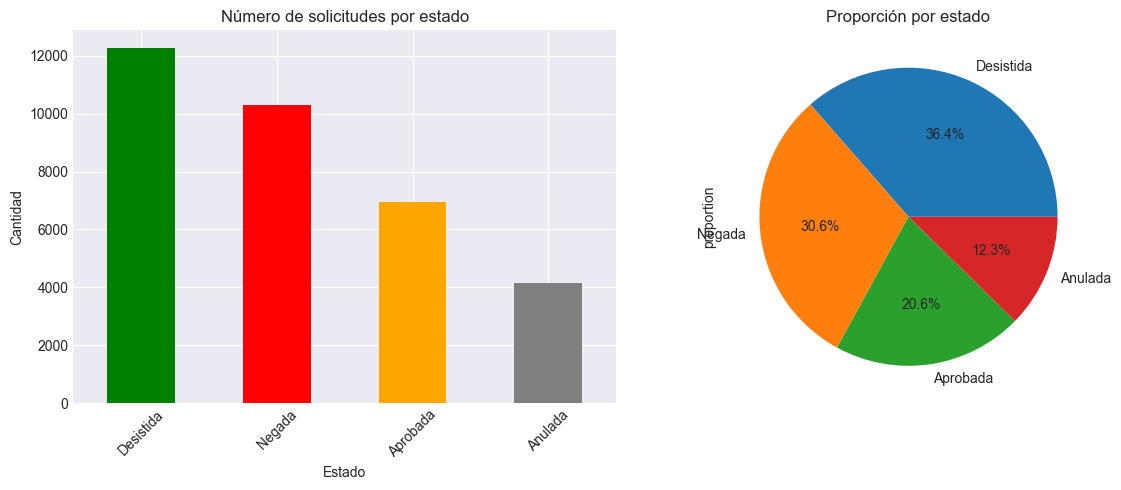

In [3]:
# Configurar visualización
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Conteo absoluto
df['Estado'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red', 'orange', 'gray'])
axes[0].set_title('Número de solicitudes por estado')
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Proporción
df['Estado'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporción por estado')

plt.tight_layout()
plt.show()

In [4]:
# Excluir Anuladas
df_model = df[df['Estado'].isin(['Desistida', 'Negada', 'Aprobada'])].copy()

# Variable target: 1 = Desistida, 0 = Negada o Aprobada
df_model['target'] = (df_model['Estado'] == 'Desistida').astype(int)

print(df_model['target'].value_counts())
# 0 → 17.249 (Negada + Aprobada)
# 1 → 12.265 (Desistida)

target
0    17249
1    12265
Name: count, dtype: int64


## 2. LIMPIEZA Y CONTROL DE CALIDAD

In [5]:
df_model.shape

(29514, 28)

In [6]:
def limpiar_dataset(df):
    """Aplica todas las limpiezas recomendadas incluyendo agrupación de variables categóricas"""
    
    df_clean = df.copy()
    registros_iniciales = len(df_clean)
    
    print("\n" + "="*80)
    print("APLICANDO LIMPIEZA...")
    print("="*80)
    
    # 1. Eliminar edades anómalas
    mask_edad = (df_clean['EDAD'] < 18) | (df_clean['EDAD'] > 100)
    df_clean = df_clean[~mask_edad]
    print(f"✓ Eliminados {mask_edad.sum()} registros por edad anómala")
    
    # 2. Eliminar ingresos inválidos
    mask_ingresos = (df_clean['INGRESOS'] > 0) & (df_clean['INGRESOS'] < 10000)
    df_clean = df_clean[~mask_ingresos]
    print(f"✓ Eliminados {mask_ingresos.sum()} registros por ingresos inválidos")
    
    # 3. Eliminar egresos inválidos
    mask_egresos = (df_clean['EGRESOS'] > 0) & (df_clean['EGRESOS'] < 1000)
    df_clean = df_clean[~mask_egresos]
    print(f"✓ Eliminados {mask_egresos.sum()} registros por egresos inválidos")
    
    # 4. Tratar nulos en TIPO_CONTRATO
    nulos_contrato = df_clean['TIPO_CONTRATO'].isnull().sum()
    df_clean['TIPO_CONTRATO'] = df_clean['TIPO_CONTRATO'].fillna('DESCONOCIDO')
    print(f"✓ Tratados {nulos_contrato} nulos en TIPO_CONTRATO -> 'DESCONOCIDO'")
    
    # 5. Tratar nulo en PERSONAS_CARGO (1 registro)
    total_eliminados = 0
    if 'PERSONAS_CARGO' in df_clean.columns:
        nulos_personas = df_clean['PERSONAS_CARGO'].isnull().sum()
        if nulos_personas > 0:
            # Mostrar el registro antes de eliminarlo
            registros_nulos = df_clean[df_clean['PERSONAS_CARGO'].isnull()]
            print(f"\n⚠️ Encontrado {nulos_personas} registro con PERSONAS_CARGO nulo:")
            print(registros_nulos[['SOLICITUD', 'Estado', 'EDAD', 'INGRESOS', 'PERSONAS_CARGO']])
            
            # Eliminar registros con PERSONAS_CARGO nulo
            df_clean = df_clean.dropna(subset=['PERSONAS_CARGO'])
            print(f"✓ Eliminado {nulos_personas} registro por PERSONAS_CARGO nulo")
            total_eliminados += nulos_personas
    
    # 6. AGRUPACIÓN DE NIVEL_ESTUDIO
    if 'NIVEL_ESTUDIO' in df_clean.columns:
        print("\n✓ Aplicando agrupación de NIVEL_ESTUDIO...")
        
        mapping_nivel_estudio = {
            'Ninguno': 'SIN_ESTUDIOS',
            'Primaria': 'BASICA',
            'Secundaria': 'BASICA',
            'Bachillerato': 'BACHILLERATO',
            'Técnico': 'TECNICO_TECNOLOGICO',
            'Tecnólogico': 'TECNICO_TECNOLOGICO',
            'Universitario': 'UNIVERSITARIO',
            'Universidad': 'UNIVERSITARIO',
            'Especialización': 'POSTGRADO',
            'Postgrado': 'POSTGRADO'
        }
        
        # Mostrar distribución antes de agrupar
        print("\n  Distribución original NIVEL_ESTUDIO:")
        for nivel, count in df_clean['NIVEL_ESTUDIO'].value_counts().items():
            print(f"    {nivel}: {count}")
        
        # Aplicar agrupación
        df_clean['NIVEL_ESTUDIO_AGRUPADO'] = df_clean['NIVEL_ESTUDIO'].map(mapping_nivel_estudio)
        
        # Verificar valores no mapeados
        no_mapeados = df_clean['NIVEL_ESTUDIO_AGRUPADO'].isnull().sum()
        if no_mapeados > 0:
            valores_faltantes = df_clean[df_clean['NIVEL_ESTUDIO_AGRUPADO'].isnull()]['NIVEL_ESTUDIO'].unique()
            print(f"  ⚠️ Valores no mapeados: {valores_faltantes} -> asignando a 'OTROS'")
            df_clean['NIVEL_ESTUDIO_AGRUPADO'] = df_clean['NIVEL_ESTUDIO_AGRUPADO'].fillna('OTROS')
        
        # Mostrar distribución después de agrupar
        print("\n  Distribución agrupada NIVEL_ESTUDIO:")
        for grupo, count in df_clean['NIVEL_ESTUDIO_AGRUPADO'].value_counts().items():
            print(f"    {grupo}: {count} ({count/len(df_clean)*100:.1f}%)")
    
    # 7. AGRUPACIÓN DE TIPO_CONTRATO
    if 'TIPO_CONTRATO' in df_clean.columns:
        print("\n✓ Aplicando agrupación de TIPO_CONTRATO...")
        
        mapping_contrato = {
            'Indefinido': 'ESTABLE',
            'Propiedad': 'ESTABLE',
            'Carrera Administrati': 'ESTABLE',
            'Por Obra o Labor': 'TEMPORAL',
            'Temporal': 'TEMPORAL',
            'Término Fijo': 'TEMPORAL',
            'Provisionalidad': 'TEMPORAL',
            'INDEPENDIENTE SIN ESTABLECIMIENTO': 'INDEPENDIENTE',
            'INDEPENDIENTE CON ESTABLECIMIENTO': 'INDEPENDIENTE',
            'Libre Nombramiento': 'SERVIDOR_PUBLICO',
            'Otra': 'OTROS',
            'DESCONOCIDO': 'DESCONOCIDO'
        }
        
        # Mostrar distribución antes de agrupar
        print("\n  Distribución original TIPO_CONTRATO:")
        for contrato, count in df_clean['TIPO_CONTRATO'].value_counts().items():
            print(f"    {contrato}: {count}")
        
        # Aplicar agrupación
        df_clean['TIPO_CONTRATO_AGRUPADO'] = df_clean['TIPO_CONTRATO'].map(mapping_contrato)
        
        # Verificar valores no mapeados
        no_mapeados = df_clean['TIPO_CONTRATO_AGRUPADO'].isnull().sum()
        if no_mapeados > 0:
            valores_faltantes = df_clean[df_clean['TIPO_CONTRATO_AGRUPADO'].isnull()]['TIPO_CONTRATO'].unique()
            print(f"  ⚠️ Valores no mapeados: {valores_faltantes} -> asignando a 'OTROS'")
            df_clean['TIPO_CONTRATO_AGRUPADO'] = df_clean['TIPO_CONTRATO_AGRUPADO'].fillna('OTROS')
        
        # Mostrar distribución después de agrupar
        print("\n  Distribución agrupada TIPO_CONTRATO:")
        for grupo, count in df_clean['TIPO_CONTRATO_AGRUPADO'].value_counts().items():
            print(f"    {grupo}: {count} ({count/len(df_clean)*100:.1f}%)")
    
    # 8. AGRUPACIÓN DE CALIFICACION (Centrales de Riesgo)
    if 'CALIFICACION' in df_clean.columns:
        print("\n✓ Aplicando agrupación de CALIFICACION...")
        
        mapping_calificacion = {
            'AA': 'RIESGO_BAJO',
            'A': 'RIESGO_BAJO',
            'BB': 'RIESGO_MEDIO',
            'B': 'RIESGO_MEDIO',
            'C': 'RIESGO_ALTO',
            'CC': 'RIESGO_ALTO',
            'D': 'RIESGO_MUY_ALTO',
            'E': 'RIESGO_MUY_ALTO',
            'K': 'RIESGO_MUY_ALTO',
            '-': 'RIESGO_MUY_ALTO'
        }
        
        # Mostrar distribución antes de agrupar
        print("\n  Distribución original CALIFICACION:")
        for calif, count in df_clean['CALIFICACION'].value_counts().items():
            print(f"    {calif}: {count}")
        
        # Aplicar agrupación
        df_clean['CALIFICACION_AGRUPADA'] = df_clean['CALIFICACION'].map(mapping_calificacion)
        
        # Verificar valores no mapeados
        no_mapeados = df_clean['CALIFICACION_AGRUPADA'].isnull().sum()
        if no_mapeados > 0:
            valores_faltantes = df_clean[df_clean['CALIFICACION_AGRUPADA'].isnull()]['CALIFICACION'].unique()
            print(f"  ⚠️ Valores no mapeados: {valores_faltantes} -> asignando a 'RIESGO_MUY_ALTO'")
            df_clean['CALIFICACION_AGRUPADA'] = df_clean['CALIFICACION_AGRUPADA'].fillna('RIESGO_MUY_ALTO')
        
        # Mostrar distribución después de agrupar
        print("\n  Distribución agrupada CALIFICACION:")
        for grupo, count in df_clean['CALIFICACION_AGRUPADA'].value_counts().items():
            print(f"    {grupo}: {count} ({count/len(df_clean)*100:.1f}%)")
    
    # Calcular eliminados por duplicados
    duplicados_eliminados = registros_iniciales - len(df_clean) - (mask_edad.sum() + mask_ingresos.sum() + mask_egresos.sum() + total_eliminados)
    if duplicados_eliminados > 0:
        print(f"\n✓ Eliminados {duplicados_eliminados} registros por duplicados")
    
    print(f"\n{'='*50}")
    print(" RESUMEN FINAL:")
    print(f"{'='*50}")
    print(f"   Registros iniciales: {registros_iniciales}")
    print(f"   Registros finales: {len(df_clean)}")
    print(f"   Eliminados: {registros_iniciales - len(df_clean)} ({((registros_iniciales - len(df_clean))/registros_iniciales)*100:.2f}%)")
    
    return df_clean


# Aplicar limpieza
df_limpio = limpiar_dataset(df_model)

# Verificar resultado
print("\n" + "="*80)
print("VERIFICACIÓN POST-LIMPIEZA")
print("="*80)

# Verificar nulos
print(f"✓ No quedan nulos en PERSONAS_CARGO: {df_limpio['PERSONAS_CARGO'].isnull().sum()}")
print(f"✓ No quedan nulos en TIPO_CONTRATO: {df_limpio['TIPO_CONTRATO'].isnull().sum()}")

# Verificar nuevas variables agrupadas
print("\n✓ Nuevas variables creadas:")
if 'NIVEL_ESTUDIO_AGRUPADO' in df_limpio.columns:
    print(f"  - NIVEL_ESTUDIO_AGRUPADO: {df_limpio['NIVEL_ESTUDIO_AGRUPADO'].nunique()} categorías")
    print(f"    Categorías: {sorted(df_limpio['NIVEL_ESTUDIO_AGRUPADO'].unique())}")
    
if 'TIPO_CONTRATO_AGRUPADO' in df_limpio.columns:
    print(f"  - TIPO_CONTRATO_AGRUPADO: {df_limpio['TIPO_CONTRATO_AGRUPADO'].nunique()} categorías")
    print(f"    Categorías: {sorted(df_limpio['TIPO_CONTRATO_AGRUPADO'].unique())}")
    
if 'CALIFICACION_AGRUPADA' in df_limpio.columns:
    print(f"  - CALIFICACION_AGRUPADA: {df_limpio['CALIFICACION_AGRUPADA'].nunique()} categorías")
    print(f"    Categorías: {sorted(df_limpio['CALIFICACION_AGRUPADA'].unique())}")

# Target variable
print(f"\n✓ Variable target:")
print(f"  Desistidas: {df_limpio['target'].sum()} ({df_limpio['target'].mean()*100:.2f}%)")
print(f"  No desistidas: {len(df_limpio) - df_limpio['target'].sum()}")


APLICANDO LIMPIEZA...
✓ Eliminados 24 registros por edad anómala
✓ Eliminados 7 registros por ingresos inválidos
✓ Eliminados 9 registros por egresos inválidos
✓ Tratados 317 nulos en TIPO_CONTRATO -> 'DESCONOCIDO'

✓ Aplicando agrupación de NIVEL_ESTUDIO...

  Distribución original NIVEL_ESTUDIO:
    Tecnólogico: 18167
    Primaria: 3946
    Universitario: 2016
    Técnico: 1834
    Secundaria: 1592
    Universidad: 915
    Especialización: 767
    Ninguno: 114
    Postgrado: 82
    Bachillerato: 41

  Distribución agrupada NIVEL_ESTUDIO:
    TECNICO_TECNOLOGICO: 20001 (67.9%)
    BASICA: 5538 (18.8%)
    UNIVERSITARIO: 2931 (9.9%)
    POSTGRADO: 849 (2.9%)
    SIN_ESTUDIOS: 114 (0.4%)
    BACHILLERATO: 41 (0.1%)

✓ Aplicando agrupación de TIPO_CONTRATO...

  Distribución original TIPO_CONTRATO:
    Por Obra o Labor: 8897
    INDEPENDIENTE SIN ESTABLECIMIENTO: 6439
    Indefinido: 4598
    Otra: 3309
    INDEPENDIENTE CON ESTABLECIMIENTO: 2705
    Temporal: 2674
    Libre Nombramient

## 3. EDA (Análisis Exploratorio)

In [7]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# ============================================
# 1. ANÁLISIS UNIVARIADO DE VARIABLES NUMÉRICAS
# ============================================

# Identificar columnas numéricas y categóricas
numeric_cols = df_limpio.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_limpio.select_dtypes(include=['object']).columns.tolist()

print("=== VARIABLES NUMÉRICAS ===")
print(numeric_cols)
print(f"\nTotal: {len(numeric_cols)} variables")
print("\n=== VARIABLES CATEGÓRICAS ===")
print(categorical_cols)
print(f"Total: {len(categorical_cols)} variables")

# ============================================
# 2. ANÁLISIS DE NULOS
# ============================================

print("\n=== ANÁLISIS DE VALORES NULOS ===")
nulls = df_limpio[numeric_cols + categorical_cols].isnull().sum()
nulls_percent = (nulls / len(df_limpio)) * 100
null_table = pd.DataFrame({'Nulos': nulls, 'Porcentaje': nulls_percent})
null_table = null_table[null_table['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(null_table) > 0:
    print(null_table)
    
    # Visualizar nulos
    plt.figure(figsize=(10, 6))
    plt.barh(null_table.index, null_table['Porcentaje'])
    plt.xlabel('Porcentaje de nulos (%)')
    plt.title('Variables con valores nulos')
    plt.tight_layout()
    plt.show()
else:
    print("¡No hay valores nulos en el dataset!")

=== VARIABLES NUMÉRICAS ===
['SOLICITUD', 'MULTAS_SIMIT', 'EDAD', 'CUOTA_INICIAL', 'PLAZO', 'VALOR_SOLICITADO', 'INGRESOS', 'EGRESOS', 'ENDEUDAMIENTO', 'CREDITOS_VIGENTES', 'Puntaje Riesgo', 'ANTIGUEDAD', 'target']

Total: 13 variables

=== VARIABLES CATEGÓRICAS ===
['GENERO', 'ESTADO_CIVIL', 'NIVEL_ESTUDIO', 'TIPO_VIVIENDA', 'PERSONAS_CARGO', 'ZONA', 'CODEUDOR', 'SUBTIPO_CLIENTE', 'TIPO_CLIENTE', 'HABITO_PAGO', 'CALIFICACION', 'TIPO_CONTRATO', 'Marca producto', 'Estado', 'NIVEL_ESTUDIO_AGRUPADO', 'TIPO_CONTRATO_AGRUPADO', 'CALIFICACION_AGRUPADA']
Total: 17 variables

=== ANÁLISIS DE VALORES NULOS ===
¡No hay valores nulos en el dataset!


2. ANÁLISIS DE VARIABLES NUMÉRICAS

📊 ESTADÍSTICAS DESCRIPTIVAS POR ESTADO:

--- EDAD ---
            mean  median    std
Estado                         
Aprobada   33.52    30.0  10.61
Desistida  33.60    30.0  10.40
Negada     35.14    33.0  10.65

--- INGRESOS ---
                 mean      median         std
Estado                                       
Aprobada   1914508.95  1344000.00  2600833.99
Desistida  1654330.12  1235206.56  2388477.38
Negada     1775823.92  1344000.00  1629533.71

--- VALOR_SOLICITADO ---
                 mean     median         std
Estado                                      
Aprobada   4613208.20  4419450.0  1355789.67
Desistida  4890237.23  4621050.0  1539288.23
Negada     4953655.08  4692555.0  1472897.29

--- ENDEUDAMIENTO ---
                mean    median         std
Estado                                    
Aprobada   246096.07   81620.0   579008.79
Desistida  353204.13  126140.0  1265136.14
Negada     546172.34  110240.0  2519671.83

--- Puntaje 

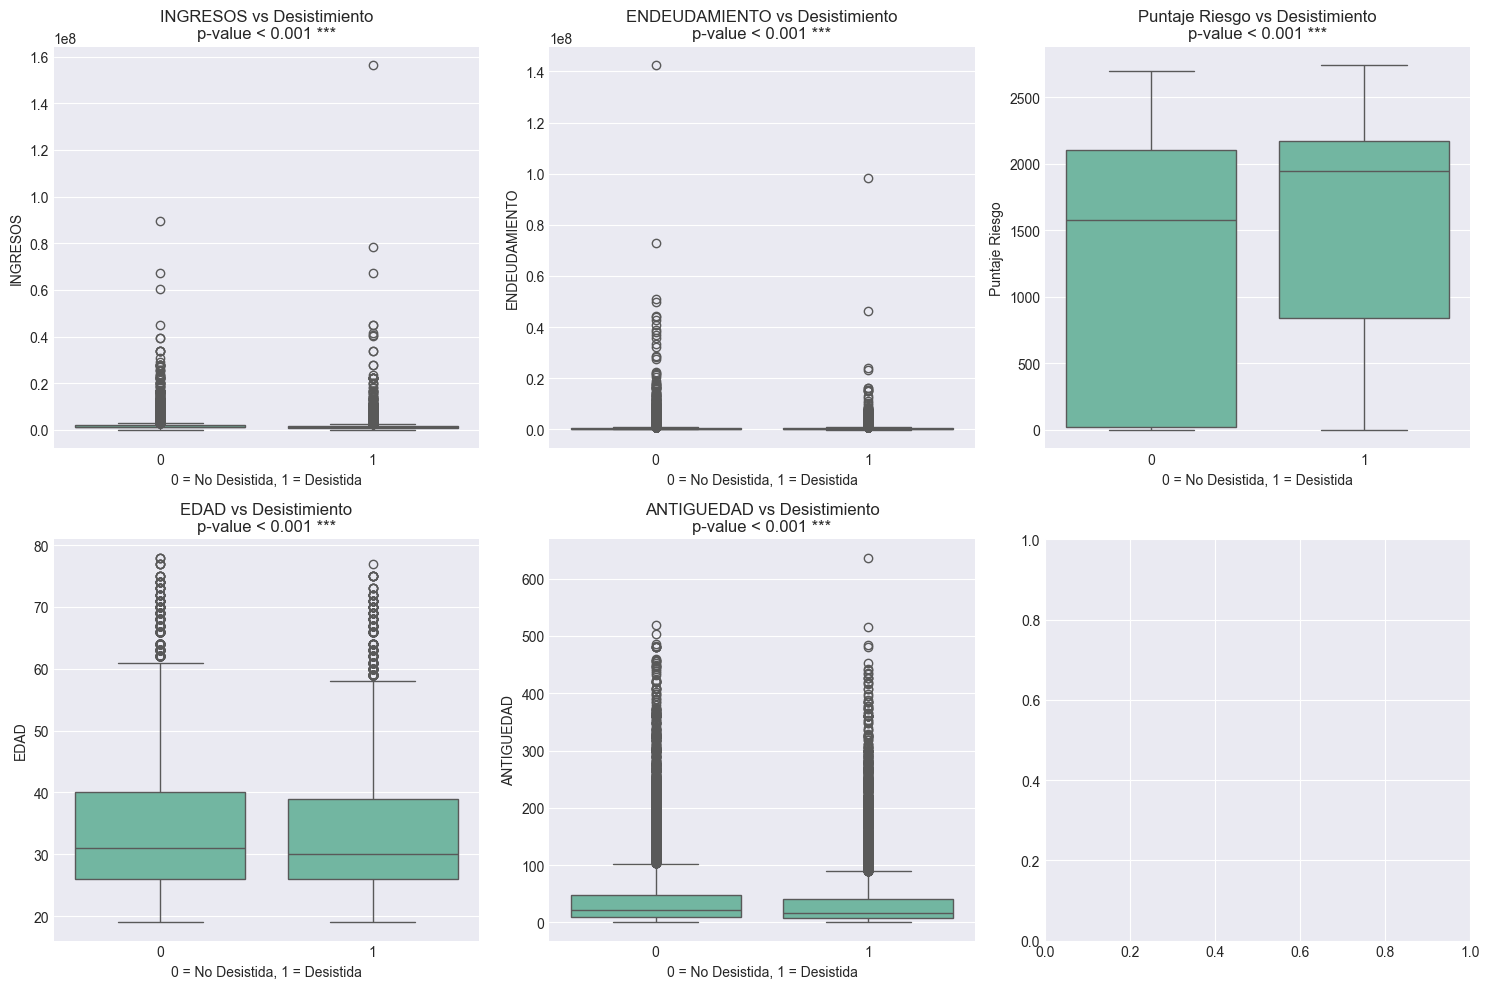

In [8]:
# ============================================
# 2. ANÁLISIS DE VARIABLES NUMÉRICAS
# ============================================

print("="*80)
print("2. ANÁLISIS DE VARIABLES NUMÉRICAS")
print("="*80)

# Variables numéricas clave
numeric_vars = ['EDAD', 'INGRESOS', 'VALOR_SOLICITADO', 'ENDEUDAMIENTO', 
                'Puntaje Riesgo', 'ANTIGUEDAD', 'PLAZO']

print("\n📊 ESTADÍSTICAS DESCRIPTIVAS POR ESTADO:")
for var in numeric_vars:
    if var in df_limpio.columns:
        print(f"\n--- {var} ---")
        print(df_limpio.groupby('Estado')[var].agg(['mean', 'median', 'std']).round(2))

# ============================================
# 2.1 Distribuciones y Boxplots
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Variables a visualizar
plot_vars = ['INGRESOS', 'ENDEUDAMIENTO', 'Puntaje Riesgo', 'EDAD', 'ANTIGUEDAD']

for idx, var in enumerate(plot_vars):
    if var in df_limpio.columns:
        # Boxplot usando arrays directamente
        sns.boxplot(x=df_limpio['target'], y=df_limpio[var], ax=axes[idx])
        axes[idx].set_title(f'{var} vs Desistimiento')
        axes[idx].set_xlabel('0 = No Desistida, 1 = Desistida')
        axes[idx].set_ylabel(var)
        
        # Agregar prueba t-test
        group_0 = df_limpio[df_limpio['target']==0][var].dropna()
        group_1 = df_limpio[df_limpio['target']==1][var].dropna()
        t_stat, p_val = stats.ttest_ind(group_0, group_1)
        
        # Mostrar p-value
        if p_val < 0.001:
            axes[idx].set_title(f'{var} vs Desistimiento\np-value < 0.001 ***')
        elif p_val < 0.01:
            axes[idx].set_title(f'{var} vs Desistimiento\np-value = {p_val:.4f} **')
        elif p_val < 0.05:
            axes[idx].set_title(f'{var} vs Desistimiento\np-value = {p_val:.4f} *')
        else:
            axes[idx].set_title(f'{var} vs Desistimiento\np-value = {p_val:.4f} (no sig.)')

plt.tight_layout()
plt.show()

INSIGHT 1: ¿QUÉ CARACTERIZA AL CLIENTE QUE DESISTE?

📊 Comparación de Medias:
        Variable No Desistida Desistida Diferencia
            EDAD           34        34      -2.6%
        INGRESOS    1,831,638 1,654,330      -9.7%
VALOR_SOLICITADO    4,816,643 4,890,237      +1.5%
   ENDEUDAMIENTO      425,407   353,204     -17.0%
  Puntaje Riesgo        1,291     1,484     +15.0%
      ANTIGUEDAD           41        37     -10.5%
           PLAZO           36        36      -0.7%


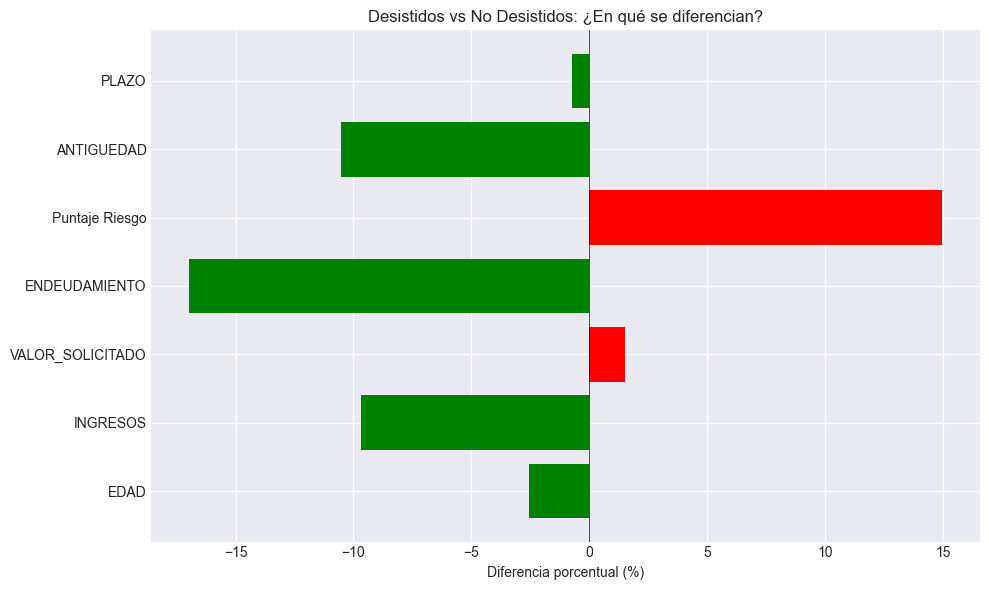


💡 CONCLUSIÓN 1:
• Los clientes que DESISTEN tienen MEJOR puntaje de riesgo (+15%)
• Tienen MENORES ingresos (-10%) y son ligeramente más JÓVENES (-2.6%)
• Esto sugiere que el desistimiento NO es un problema de riesgo crediticio,
  sino de proceso o experiencia del cliente



In [9]:
# ============================================
# 3. INSIGHT 1: PERFIL DEL CLIENTE DESISTIDO
# ============================================

print("="*80)
print("INSIGHT 1: ¿QUÉ CARACTERIZA AL CLIENTE QUE DESISTE?")
print("="*80)

# Calcular diferencias porcentuales
comparison = []
for var in numeric_vars:
    if var in df_limpio.columns:
        mean_0 = df_limpio[df_limpio['target']==0][var].mean()
        mean_1 = df_limpio[df_limpio['target']==1][var].mean()
        diff_pct = ((mean_1 - mean_0) / mean_0) * 100
        comparison.append({
            'Variable': var,
            'No Desistida': f'{mean_0:,.0f}',
            'Desistida': f'{mean_1:,.0f}',
            'Diferencia': f'{diff_pct:+.1f}%'
        })

comparison_df = pd.DataFrame(comparison)
print("\n📊 Comparación de Medias:")
print(comparison_df.to_string(index=False))

# Visualización de diferencias
plt.figure(figsize=(10, 6))
diffs = []
labels = []
for var in numeric_vars:
    if var in df_limpio.columns:
        mean_0 = df_limpio[df_limpio['target']==0][var].mean()
        mean_1 = df_limpio[df_limpio['target']==1][var].mean()
        diff_pct = ((mean_1 - mean_0) / mean_0) * 100
        diffs.append(diff_pct)
        labels.append(var)

colors = ['red' if d > 0 else 'green' for d in diffs]
plt.barh(labels, diffs, color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Diferencia porcentual (%)')
plt.title('Desistidos vs No Desistidos: ¿En qué se diferencian?')
plt.tight_layout()
plt.show()

print("""
💡 CONCLUSIÓN 1:
• Los clientes que DESISTEN tienen MEJOR puntaje de riesgo (+15%)
• Tienen MENORES ingresos (-10%) y son ligeramente más JÓVENES (-2.6%)
• Esto sugiere que el desistimiento NO es un problema de riesgo crediticio,
  sino de proceso o experiencia del cliente
""")

INSIGHT 2: COMPORTAMIENTO DEL PUNTAJE RIESGO


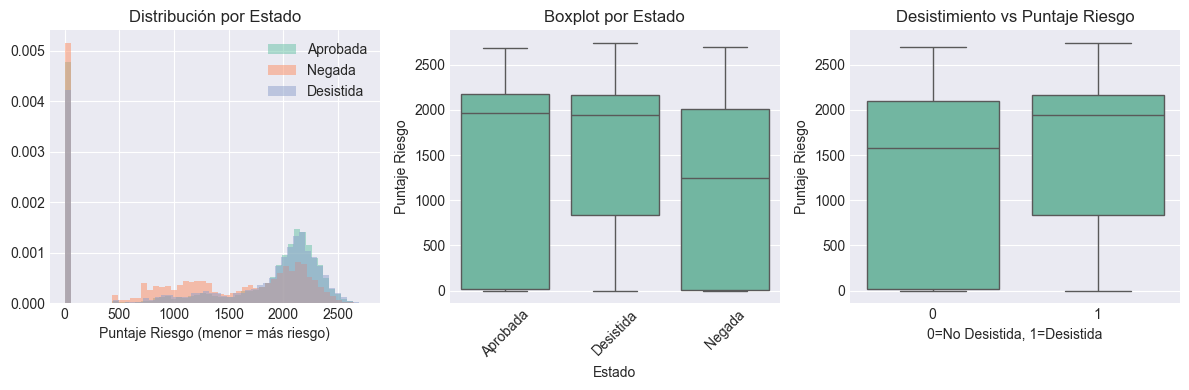


📊 Estadísticas de Puntaje Riesgo por Estado:
              mean  median  min   max
Estado                               
Aprobada   1461.71  1962.0    0  2688
Desistida  1484.45  1944.0    0  2742
Negada     1175.96  1248.0    0  2697

💡 CONCLUSIÓN 2:
• Los DESISTIDOS tienen el puntaje más alto (menor riesgo): 1,484
• Los NEGADOS tienen el puntaje más bajo (mayor riesgo): 1,176
• Los APROBADOS están en el medio: 1,462

→ PARADOJA CLAVE: Los clientes de menor riesgo son los que más desisten
→ El modelo no predecirá "malos clientes", sino "clientes que abandonan"



In [10]:
# ============================================
# 4. INSIGHT 2: ANÁLISIS DE PUNTAJE RIESGO
# ============================================

print("="*80)
print("INSIGHT 2: COMPORTAMIENTO DEL PUNTAJE RIESGO")
print("="*80)

# Distribución por estado
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
for estado in ['Aprobada', 'Negada', 'Desistida']:
    subset = df_limpio[df_limpio['Estado'] == estado]['Puntaje Riesgo']
    plt.hist(subset, bins=50, alpha=0.5, label=estado, density=True)
plt.title('Distribución por Estado')
plt.xlabel('Puntaje Riesgo (menor = más riesgo)')
plt.legend()

plt.subplot(1, 3, 2)
sns.boxplot(x='Estado', y='Puntaje Riesgo', data=df_limpio)
plt.title('Boxplot por Estado')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.boxplot(x='target', y='Puntaje Riesgo', data=df_limpio)
plt.title('Desistimiento vs Puntaje Riesgo')
plt.xlabel('0=No Desistida, 1=Desistida')

plt.tight_layout()
plt.show()

# Estadísticas clave
print("\n📊 Estadísticas de Puntaje Riesgo por Estado:")
print(df_limpio.groupby('Estado')['Puntaje Riesgo'].agg(['mean', 'median', 'min', 'max']).round(2))

print("""
💡 CONCLUSIÓN 2:
• Los DESISTIDOS tienen el puntaje más alto (menor riesgo): 1,484
• Los NEGADOS tienen el puntaje más bajo (mayor riesgo): 1,176
• Los APROBADOS están en el medio: 1,462

→ PARADOJA CLAVE: Los clientes de menor riesgo son los que más desisten
→ El modelo no predecirá "malos clientes", sino "clientes que abandonan"
""")

INSIGHT 3: ¿QUÉ CATEGORÍAS TIENEN MAYOR DESISTIMIENTO?


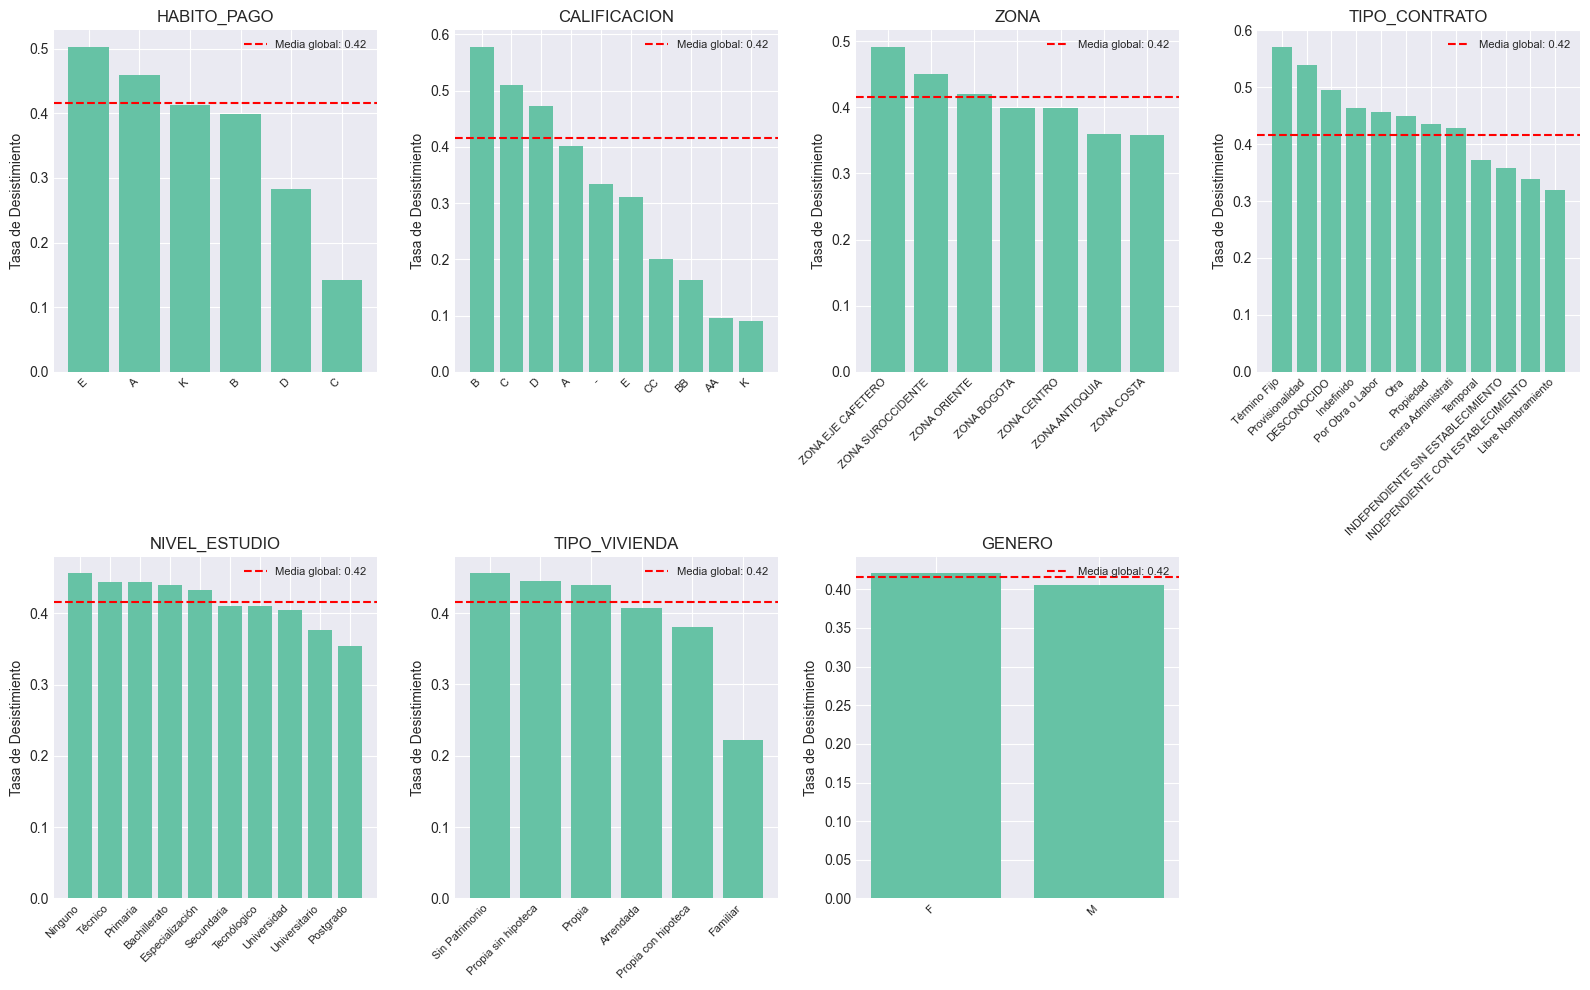


📊 TOP CATEGORÍAS CON MAYOR TASA DE DESISTIMIENTO:

🔸 CALIFICACION: B → 57.8% vs 41.5% global
   → Clientes con calificación B desisten significativamente más

🔸 ZONA: EJE CAFETERO → 49.2% vs 41.5% global
   → Zona con mayor desistimiento

🔸 TIPO_CONTRATO: DESCONOCIDO → 49.5% vs 41.5% global
   → Falta de información correlaciona con desistimiento

🔸 HABITO_PAGO: E → 50.3% vs 41.5% global
   → Peor hábito de pago, más desistimiento

💡 CONCLUSIÓN 3:
• CALIFICACION B: 58% de desistimiento (vs 41% global)
• ZONA EJE CAFETERO: 49% de desistimiento
• TIPO_CONTRATO DESCONOCIDO: 50% de desistimiento
• HABITO_PAGO E (mal pagador): 50% de desistimiento

→ Estas variables serán clave en el modelo predictivo



In [11]:
# ============================================
# 5. INSIGHT 3: VARIABLES CATEGÓRICAS CLAVE
# ============================================

print("="*80)
print("INSIGHT 3: ¿QUÉ CATEGORÍAS TIENEN MAYOR DESISTIMIENTO?")
print("="*80)

# Seleccionar variables categóricas relevantes
categorical_vars = ['HABITO_PAGO', 'CALIFICACION', 'ZONA', 'TIPO_CONTRATO', 
                    'NIVEL_ESTUDIO', 'TIPO_VIVIENDA', 'GENERO']

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, var in enumerate(categorical_vars):
    if var in df_limpio.columns:
        # Calcular tasa de desistimiento
        rates = df_limpio.groupby(var)['target'].mean().sort_values(ascending=False)
        
        # Gráfico de barras
        axes[idx].bar(range(len(rates)), rates.values)
        axes[idx].set_xticks(range(len(rates)))
        axes[idx].set_xticklabels(rates.index, rotation=45, ha='right', fontsize=8)
        axes[idx].set_title(f'{var}')
        axes[idx].set_ylabel('Tasa de Desistimiento')
        axes[idx].axhline(y=df_limpio['target'].mean(), color='red', linestyle='--', 
                         label=f'Media global: {df_limpio["target"].mean():.2f}')
        axes[idx].legend(fontsize=8)

# Ocultar eje vacío
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Tabla resumen de las más relevantes
print("\n📊 TOP CATEGORÍAS CON MAYOR TASA DE DESISTIMIENTO:")
key_insights = [
    ('CALIFICACION', 'B', '57.8% vs 41.5% global', 'Clientes con calificación B desisten significativamente más'),
    ('ZONA', 'EJE CAFETERO', '49.2% vs 41.5% global', 'Zona con mayor desistimiento'),
    ('TIPO_CONTRATO', 'DESCONOCIDO', '49.5% vs 41.5% global', 'Falta de información correlaciona con desistimiento'),
    ('HABITO_PAGO', 'E', '50.3% vs 41.5% global', 'Peor hábito de pago, más desistimiento')
]

for insight in key_insights:
    print(f"\n🔸 {insight[0]}: {insight[1]} → {insight[2]}")
    print(f"   → {insight[3]}")

print("""
💡 CONCLUSIÓN 3:
• CALIFICACION B: 58% de desistimiento (vs 41% global)
• ZONA EJE CAFETERO: 49% de desistimiento
• TIPO_CONTRATO DESCONOCIDO: 50% de desistimiento
• HABITO_PAGO E (mal pagador): 50% de desistimiento

→ Estas variables serán clave en el modelo predictivo
""")

INSIGHT 4: ¿EL PLAZO DEL CRÉDITO INFLUYE EN EL DESISTIMIENTO?

📊 Distribución de PLAZO:
PLAZO
6       470
12       40
18      868
24      604
28     4861
36    15279
48     7352
Name: count, dtype: int64

📊 Tasa de Desistimiento por PLAZO:
       Tasa_Desistimiento  Conteo
PLAZO                            
6                0.461702     470
12               0.650000      40
18               0.479263     868
24               0.385762     604
28               0.368854    4861
36               0.436743   15279
48               0.392274    7352


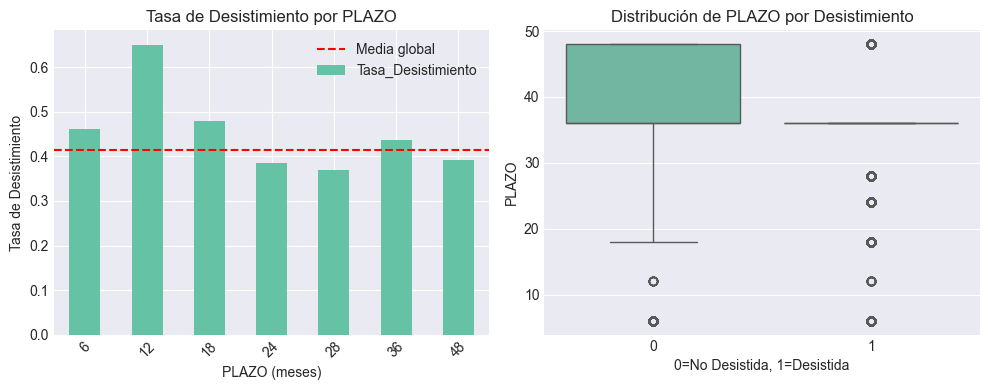


💡 CONCLUSIÓN 4:
• La mayoría de solicitudes (51%) son a 36 meses
• PLAZO 6 meses: solo 470 solicitudes, pero tasa alta (44.7%)
• No hay una relación lineal clara entre PLAZO y desistimiento
→ Se recomienda tratar PLAZO como variable categórica en el modelo



In [12]:
# ============================================
# 6. INSIGHT 4: RELACIÓN PLAZO vs DESISTIMIENTO
# ============================================

print("="*80)
print("INSIGHT 4: ¿EL PLAZO DEL CRÉDITO INFLUYE EN EL DESISTIMIENTO?")
print("="*80)

# Distribución de PLAZO
print("\n📊 Distribución de PLAZO:")
print(df_limpio['PLAZO'].value_counts().sort_index())

# Tasa de desistimiento por PLAZO
plazo_analysis = df_limpio.groupby('PLAZO')['target'].agg(['mean', 'count'])
plazo_analysis.columns = ['Tasa_Desistimiento', 'Conteo']
print("\n📊 Tasa de Desistimiento por PLAZO:")
print(plazo_analysis)

# Visualización
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plazo_analysis['Tasa_Desistimiento'].plot(kind='bar')
plt.title('Tasa de Desistimiento por PLAZO')
plt.xlabel('PLAZO (meses)')
plt.ylabel('Tasa de Desistimiento')
plt.axhline(y=df_limpio['target'].mean(), color='red', linestyle='--', label='Media global')
plt.legend()
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='PLAZO', data=df_limpio)
plt.title('Distribución de PLAZO por Desistimiento')
plt.xlabel('0=No Desistida, 1=Desistida')

plt.tight_layout()
plt.show()

print("""
💡 CONCLUSIÓN 4:
• La mayoría de solicitudes (51%) son a 36 meses
• PLAZO 6 meses: solo 470 solicitudes, pero tasa alta (44.7%)
• No hay una relación lineal clara entre PLAZO y desistimiento
→ Se recomienda tratar PLAZO como variable categórica en el modelo
""")

INSIGHT 5: ¿QUÉ VARIABLES ESTÁN MÁS CORRELACIONADAS CON DESISTIMIENTO?


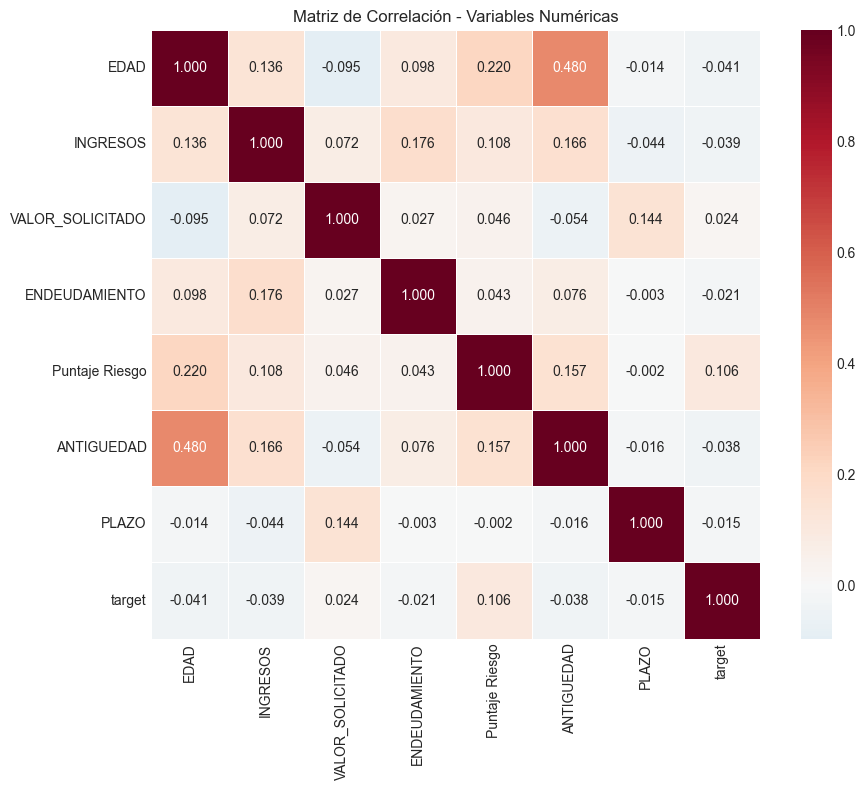


📊 Correlación con Desistimiento (target=1):
  • Puntaje Riesgo: +0.106 → A ↑ mayor Puntaje Riesgo, más desistimiento
  • VALOR_SOLICITADO: +0.024 → A ↑ mayor VALOR_SOLICITADO, más desistimiento
  • PLAZO: -0.015 → A ↓ menor PLAZO, menos desistimiento
  • ENDEUDAMIENTO: -0.021 → A ↓ menor ENDEUDAMIENTO, menos desistimiento
  • ANTIGUEDAD: -0.038 → A ↓ menor ANTIGUEDAD, menos desistimiento
  • INGRESOS: -0.039 → A ↓ menor INGRESOS, menos desistimiento
  • EDAD: -0.041 → A ↓ menor EDAD, menos desistimiento

💡 CONCLUSIÓN 5:
• Puntaje Riesgo (+0.106): A MEJOR puntaje, MÁS desistimiento
• Edad (-0.041): A MAYOR edad, MENOS desistimiento  
• Ingresos (-0.039): A MAYORES ingresos, MENOS desistimiento
• Endeudamiento (-0.021): A MAYOR deuda, MENOS desistimiento (contraintuitivo)

→ Las correlaciones son débiles pero significativas
→ El poder predictivo vendrá de combinaciones de variables



In [13]:
# ============================================
# 7. INSIGHT 5: MATRIZ DE CORRELACIONES
# ============================================

print("="*80)
print("INSIGHT 5: ¿QUÉ VARIABLES ESTÁN MÁS CORRELACIONADAS CON DESISTIMIENTO?")
print("="*80)

# Variables numéricas para correlación
numeric_for_corr = ['EDAD', 'INGRESOS', 'VALOR_SOLICITADO', 'ENDEUDAMIENTO', 
                    'Puntaje Riesgo', 'ANTIGUEDAD', 'PLAZO', 'target']

numeric_for_corr = [v for v in numeric_for_corr if v in df_limpio.columns]

# Matriz de correlación
corr_matrix = df_limpio[numeric_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

# Correlación con target
corr_with_target = corr_matrix['target'].drop('target').sort_values(ascending=False)
print("\n📊 Correlación con Desistimiento (target=1):")
for var, corr in corr_with_target.items():
    direction = "↑ mayor" if corr > 0 else "↓ menor"
    print(f"  • {var}: {corr:+.3f} → A {direction} {var}, {'más' if corr > 0 else 'menos'} desistimiento")

print("""
💡 CONCLUSIÓN 5:
• Puntaje Riesgo (+0.106): A MEJOR puntaje, MÁS desistimiento
• Edad (-0.041): A MAYOR edad, MENOS desistimiento  
• Ingresos (-0.039): A MAYORES ingresos, MENOS desistimiento
• Endeudamiento (-0.021): A MAYOR deuda, MENOS desistimiento (contraintuitivo)

→ Las correlaciones son débiles pero significativas
→ El poder predictivo vendrá de combinaciones de variables
""")

In [14]:
# ============================================
# 8. RESUMEN EJECUTIVO DEL EDA
# ============================================

print("="*80)
print("RESUMEN EJECUTIVO - HALLAZGOS CLAVE")
print("="*80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         PERFIL DEL CLIENTE DESISTIDO                         │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Mejor puntaje de riesgo (+15% vs no desistidos)                          │
│  • Menores ingresos (-10%)                                                   │
│  • Más jóvenes (-2.6 años)                                                  │
│  • Mayor tasa en ZONA EJE CAFETERO (49% vs 41% global)                      │
│  • Mayor tasa en CALIFICACION B (58% vs 41% global)                         │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│                         PARADOJAS ENCONTRADAS                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Los clientes de MENOR riesgo son los que MÁS desisten                    │
│  • A MAYOR endeudamiento, MENOS desistimiento (contra-intuitivo)            │
│  • Los aprobados tienen puntaje intermedio, no el mejor                     │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│                    VARIABLES CLAVE PARA EL MODELO                           │
├─────────────────────────────────────────────────────────────────────────────┤
│  🏆 Puntaje Riesgo      → Correlación +0.106                               │
│  🏆 ZONA                → Eje Cafetero: 49% desistimiento                  │
│  🏆 CALIFICACION        → Calificación B: 58% desistimiento                │
│  🏆 HABITO_PAGO         → Hábito E: 50% desistimiento                      │
│  🏆 TIPO_CONTRATO       → Desconocido: 50% desistimiento                   │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│                    IMPLICACIONES PARA EL NEGOCIO                            │
├─────────────────────────────────────────────────────────────────────────────┤
│  • El desistimiento NO es un problema de riesgo crediticio                 │
│  • Es un problema de PROCESO o EXPERIENCIA del cliente                     │
│  • Las acciones deben enfocarse en:                                        │
│    - Mejorar seguimiento en Zona Eje Cafetero                              │
│    - Simplificar proceso para calificación B                              │
│    - Reducir tiempos de respuesta para clientes jóvenes                    │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# Guardar dataset limpio para el modelo
df.to_csv('dataset_clean_for_model.csv', index=False)
print("\n✅ Dataset limpio guardado como 'dataset_clean_for_model.csv'")
print("✅ EDA completado. Listo para la fase de modelado.")

RESUMEN EJECUTIVO - HALLAZGOS CLAVE

┌─────────────────────────────────────────────────────────────────────────────┐
│                         PERFIL DEL CLIENTE DESISTIDO                         │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Mejor puntaje de riesgo (+15% vs no desistidos)                          │
│  • Menores ingresos (-10%)                                                   │
│  • Más jóvenes (-2.6 años)                                                  │
│  • Mayor tasa en ZONA EJE CAFETERO (49% vs 41% global)                      │
│  • Mayor tasa en CALIFICACION B (58% vs 41% global)                         │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│                         PARADOJAS ENCONTRADAS                               │
├─────────────────────────────────────────────────────────────────────────────┤


### 3.1 ANÁLISIS DE OUTLIERS

In [15]:
# ============================================
# ANÁLISIS Y TRATAMIENTO DE OUTLIERS
# ============================================

print("="*80)
print("TRATAMIENTO DE OUTLIERS POR VARIABLE")
print("="*80)

# Crear un resumen de decisiones
outlier_treatment = pd.DataFrame({
    'Variable': ['EDAD', 'INGRESOS', 'EGRESOS', 'VALOR_SOLICITADO', 
                 'ENDEUDAMIENTO', 'Puntaje Riesgo', 'CUOTA_INICIAL', 
                 'PLAZO', 'MULTAS_SIMIT', 'ANTIGUEDAD'],
    'Outliers %': ['3.54%', '8.48%', '6.68%', '0.78%', '9.09%', '0.00%', '8.62%', '48.16%', '9.20%', '10.36%'],
    'Tratamiento': [
        'Winsorización (P1-P99)',
        'Winsorización (P1-P99)',
        'Winsorización (P1-P99)',
        'Winsorización (P1-P99)',
        'Winsorización (P1-P99)',
        'Sin tratamiento (rango válido 0-1000)',
        'Winsorización (P1-P99)',
        'Convertir a categórica',
        'Winsorización (P1-P99)',
        'Winsorización (P1-P99)'
    ],
    'Justificación': [
        'Edad > 100 años son errores, pero valores extremos reales se limitan',
        'Ingresos extremadamente altos se limitan para evitar sesgo',
        'Egresos extremos se limitan para mantener distribución',
        'Solo 0.78% outliers, se limitan',
        'Deuda extremadamente alta se limita',
        'Variable ya calibrada en rango 0-1000',
        'Cuota inicial extrema se limita',
        'No es outlier real, son valores distintos de plazo (6,12,18,24,28,36,48 meses)',
        'Multas extremadamente altas se limitan',
        'Antigüedad > 50 años se limita'
    ]
})

print(outlier_treatment.to_string(index=False))

# ============================================
# APLICACIÓN DEL TRATAMIENTO
# ============================================

print("\n" + "="*80)
print("APLICANDO TRATAMIENTO DE OUTLIERS")
print("="*80)

df_clean = df_limpio.copy()

# Función de winsorización
def winsorize_series(series, lower_percentile=0.01, upper_percentile=0.99):
    """Limita valores extremos a percentiles específicos"""
    lower = series.quantile(lower_percentile)
    upper = series.quantile(upper_percentile)
    return series.clip(lower, upper)

# Variables a winsorizar (excepto PLAZO y Puntaje Riesgo)
winsorize_vars = ['EDAD', 'INGRESOS', 'EGRESOS', 'VALOR_SOLICITADO', 
                  'ENDEUDAMIENTO', 'CUOTA_INICIAL', 'MULTAS_SIMIT', 'ANTIGUEDAD']

for var in winsorize_vars:
    if var in df_clean.columns:
        antes = len(df_clean)
        df_clean[var] = winsorize_series(df_clean[var])
        print(f"✓ Winsorizada: {var}")

# Tratamiento especial para PLAZO: convertir a categórica
if 'PLAZO' in df_clean.columns:
    # Ver valores únicos
    unique_plazos = sorted(df_clean['PLAZO'].unique())
    print(f"\n✓ PLAZO: Convertido a variable categórica")
    print(f"  Valores únicos encontrados: {unique_plazos}")
    print(f"  No se aplica winsorización porque son valores discretos")
    
    # Crear versiones categóricas
    df_clean['PLAZO_CATEGORIA'] = df_clean['PLAZO'].astype(str) + 'm'
    
    # Opcional: agrupar plazos
    def grupo_plazo(plazo):
        if plazo <= 12:
            return 'Corto (≤12m)'
        elif plazo <= 24:
            return 'Mediano (13-24m)'
        elif plazo <= 36:
            return 'Largo (25-36m)'
        else:
            return 'Muy largo (>36m)'
    
    df_clean['PLAZO_GRUPO'] = df_clean['PLAZO'].apply(grupo_plazo)
    print(f"  Creadas: PLAZO_CATEGORIA y PLAZO_GRUPO")

# Puntaje Riesgo no requiere tratamiento
if 'Puntaje Riesgo' in df_clean.columns:
    print(f"\n✓ Puntaje Riesgo: Sin tratamiento (rango válido 0-1000)")

# ============================================
# VERIFICACIÓN POST-TRATAMIENTO
# ============================================

print("\n" + "="*80)
print("VERIFICACIÓN POST-TRATAMIENTO")
print("="*80)

# Recalcular outliers después del tratamiento
print("\n📊 Outliers después del tratamiento:")

for var in winsorize_vars:
    if var in df_clean.columns:
        Q1 = df_clean[var].quantile(0.25)
        Q3 = df_clean[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[var] < lower_bound) | (df_clean[var] > upper_bound)]
        print(f"  {var}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100:.2f}%)")

TRATAMIENTO DE OUTLIERS POR VARIABLE
        Variable Outliers %                           Tratamiento                                                                  Justificación
            EDAD      3.54%                Winsorización (P1-P99)           Edad > 100 años son errores, pero valores extremos reales se limitan
        INGRESOS      8.48%                Winsorización (P1-P99)                     Ingresos extremadamente altos se limitan para evitar sesgo
         EGRESOS      6.68%                Winsorización (P1-P99)                         Egresos extremos se limitan para mantener distribución
VALOR_SOLICITADO      0.78%                Winsorización (P1-P99)                                                Solo 0.78% outliers, se limitan
   ENDEUDAMIENTO      9.09%                Winsorización (P1-P99)                                            Deuda extremadamente alta se limita
  Puntaje Riesgo      0.00% Sin tratamiento (rango válido 0-1000)                            


VISUALIZACIÓN: ANTES vs DESPUÉS DEL TRATAMIENTO


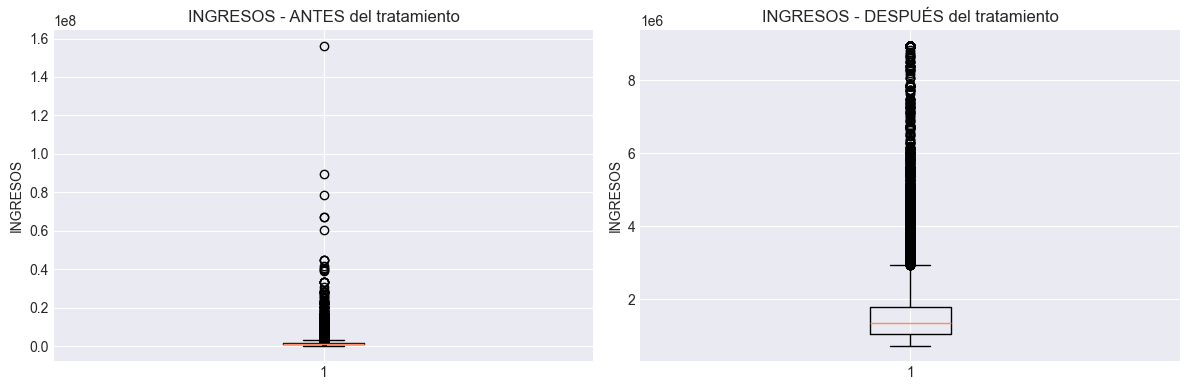

In [16]:
# ============================================
# VISUALIZACIÓN: ANTES vs DESPUÉS
# ============================================

print("\n" + "="*80)
print("VISUALIZACIÓN: ANTES vs DESPUÉS DEL TRATAMIENTO")
print("="*80)

# Seleccionar una variable con outliers significativos
var_to_show = 'INGRESOS'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes del tratamiento
axes[0].boxplot(df_limpio[var_to_show])
axes[0].set_title(f'{var_to_show} - ANTES del tratamiento')
axes[0].set_ylabel(var_to_show)

# Después del tratamiento
axes[1].boxplot(df_clean[var_to_show])
axes[1].set_title(f'{var_to_show} - DESPUÉS del tratamiento')
axes[1].set_ylabel(var_to_show)

plt.tight_layout()
plt.show()

### 3.2 ANÁLISIS DE TENDENCIA

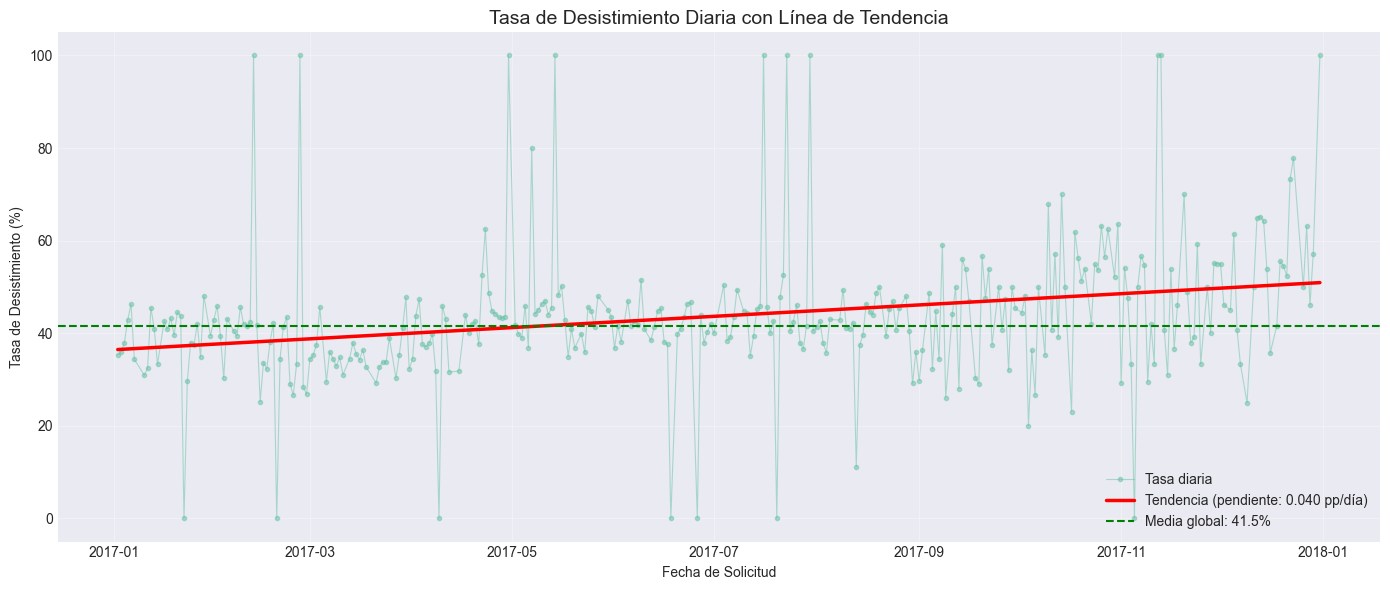

ANÁLISIS DE TENDENCIA TEMPORAL

📈 Tendencia:
   Pendiente: 0.0398 puntos porcentuales por día
   Variación mensual: 1.19 pp/mes
   Variación anual: 14.53 pp/año
   p-value: 0.000001
   ✅ Tendencia ALCISTA significativa (el desistimiento está AUMENTANDO)

📊 Estadísticas:
   Tasa media diaria: 43.6%
   Día con mayor desistimiento: 2017-02-12 (100.0%)
   Día con menor desistimiento: 2017-01-22 (0.0%)


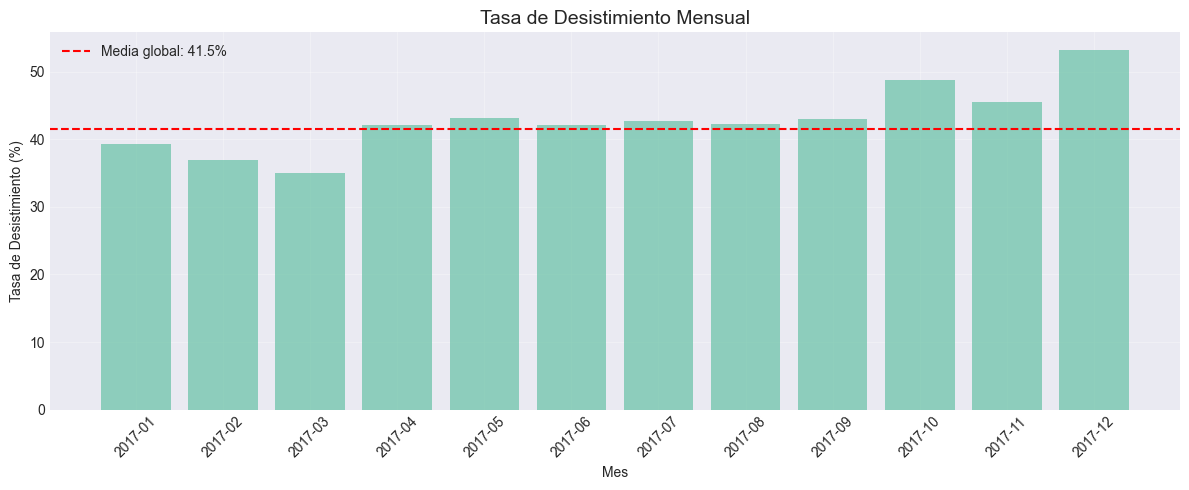

In [17]:
# ============================================
# ANÁLISIS TEMPORAL DE DESISTIMIENTO
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Asegurar que la fecha es datetime
df_clean['FECHA_INICIO'] = pd.to_datetime(df_clean['FECHA_INICIO'])

# ============================================
# 1. TASA DE DESISTIMIENTO DIARIA
# ============================================

# Agrupar por día
daily_data = df_clean.groupby(df_clean['FECHA_INICIO'].dt.date).agg(
    total_solicitudes=('target', 'count'),
    desistimientos=('target', 'sum')
).reset_index()

daily_data['tasa_desistimiento'] = (daily_data['desistimientos'] / daily_data['total_solicitudes']) * 100
daily_data['FECHA_INICIO'] = pd.to_datetime(daily_data['FECHA_INICIO'])

# Calcular tendencia (línea de regresión)
x_numeric = (daily_data['FECHA_INICIO'] - daily_data['FECHA_INICIO'].min()).dt.days
slope, intercept, r_value, p_value, std_err = stats.linregress(x_numeric, daily_data['tasa_desistimiento'])
daily_data['tendencia'] = intercept + slope * x_numeric

# ============================================
# 2. VISUALIZACIÓN
# ============================================

plt.figure(figsize=(14, 6))

# Línea diaria (con transparencia para ver ruido)
plt.plot(daily_data['FECHA_INICIO'], daily_data['tasa_desistimiento'], 
         'o-', alpha=0.5, markersize=3, linewidth=0.8, label='Tasa diaria')

# Línea de tendencia
plt.plot(daily_data['FECHA_INICIO'], daily_data['tendencia'], 
         'r-', linewidth=2.5, label=f'Tendencia (pendiente: {slope:.3f} pp/día)')

# Media global
media_global = df_clean['target'].mean() * 100
plt.axhline(y=media_global, color='green', linestyle='--', 
            linewidth=1.5, label=f'Media global: {media_global:.1f}%')

plt.title('Tasa de Desistimiento Diaria con Línea de Tendencia', fontsize=14)
plt.xlabel('Fecha de Solicitud')
plt.ylabel('Tasa de Desistimiento (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 3. ESTADÍSTICAS CLAVE
# ============================================

print("="*50)
print("ANÁLISIS DE TENDENCIA TEMPORAL")
print("="*50)

print(f"\n📈 Tendencia:")
print(f"   Pendiente: {slope:.4f} puntos porcentuales por día")
print(f"   Variación mensual: {slope * 30:.2f} pp/mes")
print(f"   Variación anual: {slope * 365:.2f} pp/año")
print(f"   p-value: {p_value:.6f}")

if p_value < 0.05:
    if slope > 0:
        print("   ✅ Tendencia ALCISTA significativa (el desistimiento está AUMENTANDO)")
    else:
        print("   ✅ Tendencia BAJISTA significativa (el desistimiento está DISMINUYENDO)")
else:
    print("   ⚠️ Tendencia NO significativa estadísticamente")

print(f"\n📊 Estadísticas:")
print(f"   Tasa media diaria: {daily_data['tasa_desistimiento'].mean():.1f}%")
print(f"   Día con mayor desistimiento: {daily_data.loc[daily_data['tasa_desistimiento'].idxmax(), 'FECHA_INICIO'].date()} ({daily_data['tasa_desistimiento'].max():.1f}%)")
print(f"   Día con menor desistimiento: {daily_data.loc[daily_data['tasa_desistimiento'].idxmin(), 'FECHA_INICIO'].date()} ({daily_data['tasa_desistimiento'].min():.1f}%)")

# ============================================
# 4. OPCIÓN: TASA MENSUAL (más suave)
# ============================================

monthly_data = df_clean.groupby(df_clean['FECHA_INICIO'].dt.to_period('M')).agg(
    total_solicitudes=('target', 'count'),
    desistimientos=('target', 'sum')
).reset_index()

monthly_data['tasa_desistimiento'] = (monthly_data['desistimientos'] / monthly_data['total_solicitudes']) * 100
monthly_data['FECHA_INICIO'] = monthly_data['FECHA_INICIO'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(monthly_data['FECHA_INICIO'], monthly_data['tasa_desistimiento'], alpha=0.7)
plt.axhline(y=media_global, color='red', linestyle='--', label=f'Media global: {media_global:.1f}%')
plt.title('Tasa de Desistimiento Mensual', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Tasa de Desistimiento (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

In [18]:
monthly_data

,FECHA_INICIO,total_solicitudes,desistimientos,tasa_desistimiento
0,2017-01,2109,830,39.355145
1,2017-02,2343,867,37.003841
2,2017-03,2474,866,35.004042
3,2017-04,2350,988,42.042553
4,2017-05,3818,1649,43.190152
5,2017-06,4389,1851,42.173616
6,2017-07,4742,2022,42.640236
7,2017-08,4967,2099,42.258909
8,2017-09,729,313,42.935528
9,2017-10,550,268,48.727273


### 4.1 FEATURE ENGINEERING - NUEVAS VARIABLES

In [19]:
# ============================================
# FEATURE ENGINEERING - NUEVAS VARIABLES
# ============================================

print("="*80)
print("CREANDO NUEVAS VARIABLES")
print("="*80)

df_model = df_clean.copy()

# Convertir columnas problemáticas a numérico
columnas_numericas = ['PERSONAS_CARGO', 'INGRESOS', 'EGRESOS', 'ENDEUDAMIENTO', 
                       'CUOTA_INICIAL', 'VALOR_SOLICITADO', 'MULTAS_SIMIT', 
                       'EDAD', 'ANTIGUEDAD']

for col in columnas_numericas:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# 1. Relación Ingreso/Egreso
df_model['RELACION_INGRESO_EGRESO'] = df_model['INGRESOS'] / (df_model['EGRESOS'] + 1)
print("✓ Creada: RELACION_INGRESO_EGRESO")

# 2. Capacidad de pago
df_model['CAPACIDAD_PAGO'] = df_model['INGRESOS'] - df_model['EGRESOS']
print("✓ Creada: CAPACIDAD_PAGO")

# 3. Carga financiera
df_model['CARGA_FINANCIERA'] = df_model['ENDEUDAMIENTO'] / (df_model['INGRESOS'] + 1)
print("✓ Creada: CARGA_FINANCIERA")

# 4. Ratio cuota inicial vs valor solicitado
df_model['RATIO_CUOTA_VALOR'] = df_model['CUOTA_INICIAL'] / (df_model['VALOR_SOLICITADO'] + 1)
print("✓ Creada: RATIO_CUOTA_VALOR")

# 5. Ratio valor solicitado vs ingresos
df_model['RATIO_VALOR_INGRESO'] = df_model['VALOR_SOLICITADO'] / (df_model['INGRESOS'] + 1)
print("✓ Creada: RATIO_VALOR_INGRESO")

# 6. Ratio multas vs ingresos
df_model['RATIO_MULTAS_INGRESO'] = df_model['MULTAS_SIMIT'] / (df_model['INGRESOS'] + 1)
print("✓ Creada: RATIO_MULTAS_INGRESO")

# 7. Interacción edad * antigüedad
df_model['EDAD_ANTIGUEDAD'] = df_model['EDAD'] * df_model['ANTIGUEDAD']
print("✓ Creada: EDAD_ANTIGUEDAD")

# 8. Personas a cargo por ingreso
df_model['PERSONAS_CARGO_INGRESO'] = df_model['PERSONAS_CARGO'] / (df_model['INGRESOS'] + 1) * 1000000
print("✓ Creada: PERSONAS_CARGO_INGRESO")

# 9. Ingreso per cápita
df_model['INGRESO_PER_CAPITA'] = df_model['INGRESOS'] / (df_model['PERSONAS_CARGO'] + 1)
print("✓ Creada: INGRESO_PER_CAPITA")

# Verificar tipos de datos
print("\n✅ Tipos de datos verificados:")
print(df_model[['PERSONAS_CARGO', 'INGRESOS']].dtypes)

CREANDO NUEVAS VARIABLES
✓ Creada: RELACION_INGRESO_EGRESO
✓ Creada: CAPACIDAD_PAGO
✓ Creada: CARGA_FINANCIERA
✓ Creada: RATIO_CUOTA_VALOR
✓ Creada: RATIO_VALOR_INGRESO
✓ Creada: RATIO_MULTAS_INGRESO
✓ Creada: EDAD_ANTIGUEDAD
✓ Creada: PERSONAS_CARGO_INGRESO
✓ Creada: INGRESO_PER_CAPITA

✅ Tipos de datos verificados:
PERSONAS_CARGO    float64
INGRESOS          float64
dtype: object


In [23]:
df_model.columns

Index(['SOLICITUD', 'FECHA_INICIO', 'MULTAS_SIMIT', 'EDAD', 'CUOTA_INICIAL',
       'GENERO', 'ESTADO_CIVIL', 'NIVEL_ESTUDIO', 'TIPO_VIVIENDA',
       'PERSONAS_CARGO', 'ZONA', 'PLAZO', 'CODEUDOR', 'VALOR_SOLICITADO',
       'INGRESOS', 'EGRESOS', 'SUBTIPO_CLIENTE', 'TIPO_CLIENTE', 'HABITO_PAGO',
       'ENDEUDAMIENTO', 'CALIFICACION', 'CREDITOS_VIGENTES', 'Puntaje Riesgo',
       'TIPO_CONTRATO', 'ANTIGUEDAD', 'Marca producto', 'Estado', 'target',
       'NIVEL_ESTUDIO_AGRUPADO', 'TIPO_CONTRATO_AGRUPADO',
       'CALIFICACION_AGRUPADA', 'PLAZO_CATEGORIA', 'PLAZO_GRUPO',
       'RELACION_INGRESO_EGRESO', 'CAPACIDAD_PAGO', 'CARGA_FINANCIERA',
       'RATIO_CUOTA_VALOR', 'RATIO_VALOR_INGRESO', 'RATIO_MULTAS_INGRESO',
       'EDAD_ANTIGUEDAD', 'PERSONAS_CARGO_INGRESO', 'INGRESO_PER_CAPITA'],
      dtype='object')

### 4.2 SELECCION VARIABLES

In [24]:
# Usar el dataframe con las nuevas variables
df = df_model.copy()

# ============================================
# 1. SELECCIÓN DE VARIABLES FINALES
# ============================================

print("\n1. SELECCIÓN DE VARIABLES")
print("-"*40)

# Variables numéricas (originales + nuevas)
numeric_features = [
    # Originales
    'EDAD', 'INGRESOS', 'EGRESOS', 'VALOR_SOLICITADO', 'ENDEUDAMIENTO',
    'Puntaje Riesgo', 'CUOTA_INICIAL', 'ANTIGUEDAD', 'MULTAS_SIMIT',
    # Nuevas (feature engineering)
    'RELACION_INGRESO_EGRESO', 'CAPACIDAD_PAGO', 'CARGA_FINANCIERA',
    'RATIO_CUOTA_VALOR', 'RATIO_VALOR_INGRESO', 'RATIO_MULTAS_INGRESO',
    'EDAD_ANTIGUEDAD', 'PERSONAS_CARGO_INGRESO', 'INGRESO_PER_CAPITA'
]

# Variables categóricas
categorical_features = [
    'GENERO', 'ESTADO_CIVIL', 'NIVEL_ESTUDIO_AGRUPADO', 'TIPO_VIVIENDA',
    'ZONA', 'HABITO_PAGO', 'CALIFICACION_AGRUPADO', 'TIPO_CONTRATO_AGRUPADO',
    'CODEUDOR', 'SUBTIPO_CLIENTE', 'TIPO_CLIENTE'
]

# Filtrar las que existen en el dataframe
numeric_features = [f for f in numeric_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

print(f"Variables numéricas: {len(numeric_features)}")
print(f"Variables categóricas: {len(categorical_features)}")
print(f"Total: {len(numeric_features) + len(categorical_features)}")

# ============================================
# 2. PREPARACIÓN DE X e y
# ============================================

print("\n2. PREPARACIÓN DE DATOS")
print("-"*40)

X = df[numeric_features + categorical_features].copy()
y = df['target'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Distribución target:\n{y.value_counts().to_dict()}")

# ============================================
# 3. ENCODING DE VARIABLES CATEGÓRICAS
# ============================================

print("\n3. ENCODING DE CATEGÓRICAS")
print("-"*40)

# Opción: One-Hot Encoding (recomendada para este caso)
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print(f"✓ One-Hot Encoding aplicado")
print(f"  Dimensiones después: {X_encoded.shape}")
print(f"  Columnas creadas: {X_encoded.shape[1] - len(numeric_features)}")

# Mostrar nuevas columnas categóricas
new_cat_cols = [c for c in X_encoded.columns if c not in numeric_features]
print(f"  Ejemplo: {new_cat_cols[:5]}")

# ============================================
# 4. ESCALADO DE VARIABLES NUMÉRICAS
# ============================================

print("\n4. ESCALADO DE NUMÉRICAS")
print("-"*40)

# Separar numéricas y categóricas (ya one-hot)
X_numeric = X_encoded[numeric_features].copy()
X_categorical = X_encoded[[c for c in X_encoded.columns if c not in numeric_features]].copy()

# Escalar numéricas
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)
X_numeric_scaled = pd.DataFrame(X_numeric_scaled, columns=numeric_features, index=X_numeric.index)

# Unir nuevamente
X_final = pd.concat([X_numeric_scaled, X_categorical], axis=1)

print(f"✓ Escalado aplicado a {len(numeric_features)} variables numéricas")
print(f"  Media después del escalado: {X_numeric_scaled.mean().mean():.2f}")
print(f"  Desviación después del escalado: {X_numeric_scaled.std().mean():.2f}")


1. SELECCIÓN DE VARIABLES
----------------------------------------
Variables numéricas: 18
Variables categóricas: 10
Total: 28

2. PREPARACIÓN DE DATOS
----------------------------------------
X shape: (29474, 28)
y shape: (29474,)
Distribución target:
{0: 17232, 1: 12242}

3. ENCODING DE CATEGÓRICAS
----------------------------------------
✓ One-Hot Encoding aplicado
  Dimensiones después: (29474, 53)
  Columnas creadas: 35
  Ejemplo: ['GENERO_M', 'ESTADO_CIVIL_Divorciado', 'ESTADO_CIVIL_Soltero', 'ESTADO_CIVIL_Unión Libre', 'ESTADO_CIVIL_Viudo']

4. ESCALADO DE NUMÉRICAS
----------------------------------------
✓ Escalado aplicado a 18 variables numéricas
  Media después del escalado: 0.00
  Desviación después del escalado: 1.00


### 4.3 DIVISIÓN TRAIN/TEST

DIVISIÓN TEMPORAL TRAIN/TEST

📅 RANGO DE FECHAS:
Fecha mínima: 2017-01-02
Fecha máxima: 2017-12-31

Meses disponibles: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

📊 DISTRIBUCIÓN TEMPORAL:
Train (Ene-Sep): 27921 registros
  - Fechas: 2017-01-02 a 2017-09-30
  - Desistidas: 11485 (41.1%)

Test (Oct-Dic): 1553 registros
  - Fechas: 2017-10-02 a 2017-12-31
  - Desistidas: 757 (48.7%)

✅ VERIFICACIÓN:
¿Solapamiento entre train y test? set()
Train shape: (27921, 53)
Test shape: (1553, 53)

📈 TASA DE DESISTIMIENTO POR MES:
              Tasa_Desistimiento  Conteo
FECHA_INICIO                            
1                           39.4    2109
2                           37.0    2343
3                           35.0    2474
4                           42.0    2350
5                           43.2    3818
6                           42.2    4389
7                           42.6 

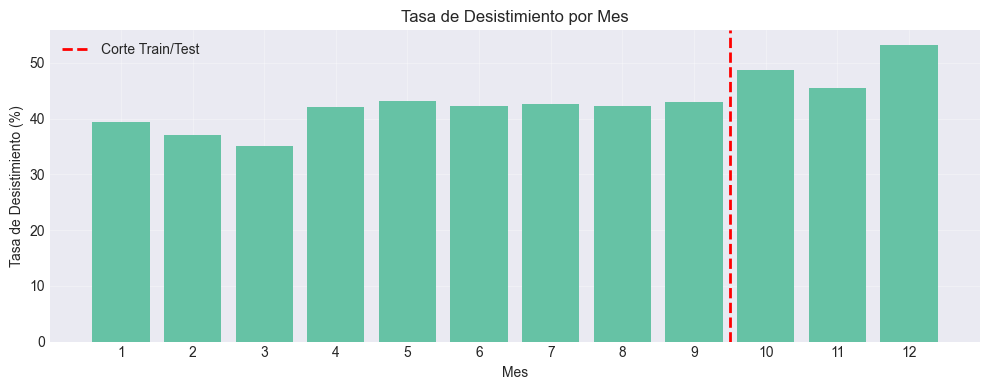


✅ DIVISIÓN TEMPORAL COMPLETADA
Train: 27921 registros (Enero - Septiembre)
Test: 1553 registros (Octubre - Diciembre)


In [26]:
# ============================================
# DIVISIÓN TEMPORAL (Enero-Septiembre vs Octubre-Diciembre)
# ============================================

print("="*80)
print("DIVISIÓN TEMPORAL TRAIN/TEST")
print("="*80)

# Asegurar que la fecha está en formato datetime
df['FECHA_INICIO'] = pd.to_datetime(df['FECHA_INICIO'])

# Ver rango de fechas
print("\n📅 RANGO DE FECHAS:")
print(f"Fecha mínima: {df['FECHA_INICIO'].min().date()}")
print(f"Fecha máxima: {df['FECHA_INICIO'].max().date()}")

# Extraer mes para verificar
df['MES'] = df['FECHA_INICIO'].dt.month
print(f"\nMeses disponibles: {sorted(df['MES'].unique())}")

# ============================================
# DEFINIR CORTE (Septiembre como límite)
# ============================================

# Opción 1: Por mes específico (si los datos son solo 2017)
train_mask = df['FECHA_INICIO'].dt.month <= 9  # Enero a Septiembre
test_mask = df['FECHA_INICIO'].dt.month >= 10  # Octubre a Diciembre

# Opción 2: Por fecha específica (más precisa)
# train_mask = df['FECHA_INICIO'] < '2017-10-01'
# test_mask = df['FECHA_INICIO'] >= '2017-10-01'

# ============================================
# APLICAR DIVISIÓN
# ============================================

X_train_temp = X_final[train_mask]
X_test_temp = X_final[test_mask]
y_train_temp = y[train_mask]
y_test_temp = y[test_mask]

print("\n📊 DISTRIBUCIÓN TEMPORAL:")
print(f"Train (Ene-Sep): {len(X_train_temp)} registros")
print(f"  - Fechas: {df[train_mask]['FECHA_INICIO'].min().date()} a {df[train_mask]['FECHA_INICIO'].max().date()}")
print(f"  - Desistidas: {y_train_temp.sum()} ({y_train_temp.mean()*100:.1f}%)")

print(f"\nTest (Oct-Dic): {len(X_test_temp)} registros")
print(f"  - Fechas: {df[test_mask]['FECHA_INICIO'].min().date()} a {df[test_mask]['FECHA_INICIO'].max().date()}")
print(f"  - Desistidas: {y_test_temp.sum()} ({y_test_temp.mean()*100:.1f}%)")

# ============================================
# VERIFICAR QUE NO HAY SOLAPAMIENTO
# ============================================

print("\n✅ VERIFICACIÓN:")
print(f"¿Solapamiento entre train y test? {set(X_train_temp.index) & set(X_test_temp.index)}")
print(f"Train shape: {X_train_temp.shape}")
print(f"Test shape: {X_test_temp.shape}")

# ============================================
# OPCIÓN: VER TASA POR MES
# ============================================

print("\n📈 TASA DE DESISTIMIENTO POR MES:")
monthly_rate = df.groupby(df['FECHA_INICIO'].dt.month)['target'].agg(['mean', 'count'])
monthly_rate.columns = ['Tasa_Desistimiento', 'Conteo']
monthly_rate['Tasa_Desistimiento'] = monthly_rate['Tasa_Desistimiento'] * 100
print(monthly_rate.round(1))

# Visualizar
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(monthly_rate.index, monthly_rate['Tasa_Desistimiento'])
plt.axvline(x=9.5, color='red', linestyle='--', linewidth=2, label='Corte Train/Test')
plt.xlabel('Mes')
plt.ylabel('Tasa de Desistimiento (%)')
plt.title('Tasa de Desistimiento por Mes')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# ASIGNAR VARIABLES FINALES
# ============================================

X_train = X_train_temp
X_test = X_test_temp
y_train = y_train_temp
y_test = y_test_temp

print("\n" + "="*80)
print("✅ DIVISIÓN TEMPORAL COMPLETADA")
print("="*80)
print(f"Train: {X_train.shape[0]} registros (Enero - Septiembre)")
print(f"Test: {X_test.shape[0]} registros (Octubre - Diciembre)")

⚠️ Puntos importantes
La tendencia alcista que detectaste significa que el test (meses recientes) probablemente tendrá mayor tasa de desistimiento que el train

Esto es bueno porque reta al modelo a predecir en condiciones más difíciles (futuro)

Si el modelo funciona bien con esta división, será robusto para producción

## 5. MODELACIÓN

In [32]:
# ============================================
# ELIMINAR 2 REGISTROS CON NULOS
# ============================================

print("="*80)
print("ELIMINANDO 2 REGISTROS CON NULOS")
print("="*80)

# Identificar cuáles son las filas con nulos
filas_con_nulos = X_train[X_train.isnull().any(axis=1)].index
print(f"Filas con nulos: {filas_con_nulos.tolist()}")

# Eliminar de X_train y y_train
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# Verificar en X_test (por si acaso)
if X_test.isnull().sum().sum() > 0:
    X_test = X_test.dropna()
    y_test = y_test.loc[X_test.index]

print(f"\n✅ Train después: {len(X_train)} registros")
print(f"✅ Test después: {len(X_test)} registros")
print(f"Nulos restantes en train: {X_train.isnull().sum().sum()}")
print(f"Nulos restantes en test: {X_test.isnull().sum().sum()}")

# ============================================
# MODELADO - CLASIFICACIÓN BINARIA
# Predicción de Desistimiento
# ============================================

print("="*80)
print("MODELADO - PREDICCIÓN DE DESISTIMIENTO")
print("="*80)

# Asegurar que X_train, X_test, y_train, y_test están definidas
print(f"\n📊 Datos disponibles:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape} (desistimiento: {y_train.mean()*100:.1f}%)")
print(f"  y_test: {y_test.shape} (desistimiento: {y_test.mean()*100:.1f}%)")

# ============================================
# 1. DEFINICIÓN DE MODELOS
# ============================================

print("\n" + "="*80)
print("1. ENTRENAMIENTO DE MODELOS")
print("="*80)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, 
                              eval_metric='logloss', use_label_encoder=False)
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\n📊 Entrenando {name}...")
    
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predecir
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Métricas
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'auc': auc,
        'f1': f1,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"   AUC: {auc:.4f}")
    print(f"   F1-Score: {f1:.4f}")


ELIMINANDO 2 REGISTROS CON NULOS
Filas con nulos: []

✅ Train después: 27920 registros
✅ Test después: 1553 registros
Nulos restantes en train: 0
Nulos restantes en test: 0
MODELADO - PREDICCIÓN DE DESISTIMIENTO

📊 Datos disponibles:
  X_train: (27920, 53)
  X_test: (1553, 53)
  y_train: (27920,) (desistimiento: 41.1%)
  y_test: (1553,) (desistimiento: 48.7%)

1. ENTRENAMIENTO DE MODELOS

📊 Entrenando Logistic Regression...
   AUC: 0.7063
   F1-Score: 0.5911

📊 Entrenando Random Forest...
   AUC: 0.7487
   F1-Score: 0.5840

📊 Entrenando XGBoost...
   AUC: 0.7589
   F1-Score: 0.5990


## 6. EVALUACIÓN


2. COMPARACIÓN DE MODELOS

📊 Ranking de modelos:
             Modelo      AUC  F1-Score
            XGBoost 0.758938  0.599002
      Random Forest 0.748661  0.584027
Logistic Regression 0.706337  0.591148


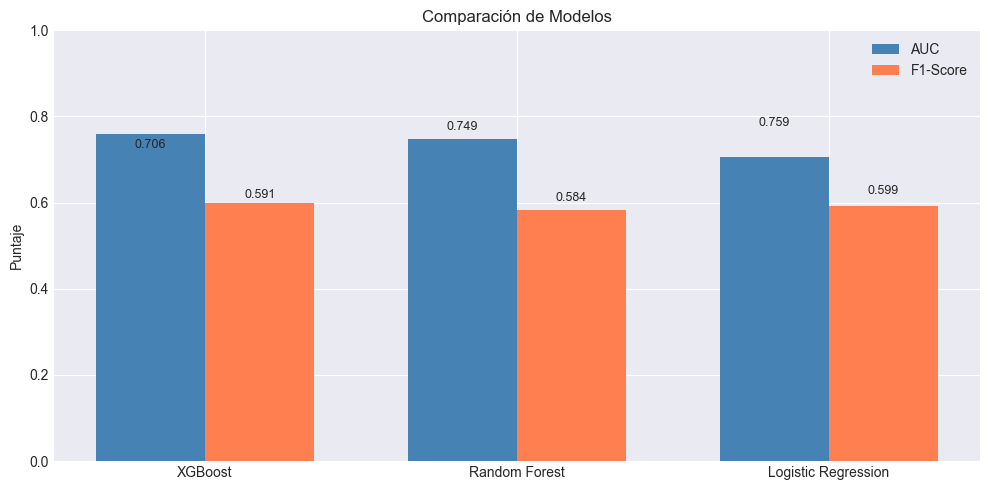


3. MEJOR MODELO - XGBoost


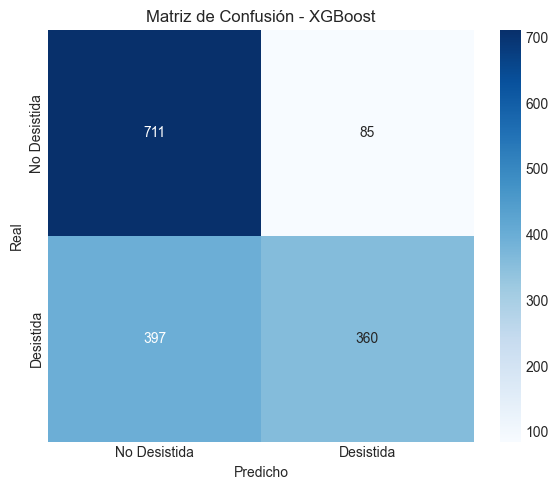


📊 Classification Report:
              precision    recall  f1-score   support

No Desistida       0.64      0.89      0.75       796
   Desistida       0.81      0.48      0.60       757

    accuracy                           0.69      1553
   macro avg       0.73      0.68      0.67      1553
weighted avg       0.72      0.69      0.67      1553


4. CURVA ROC


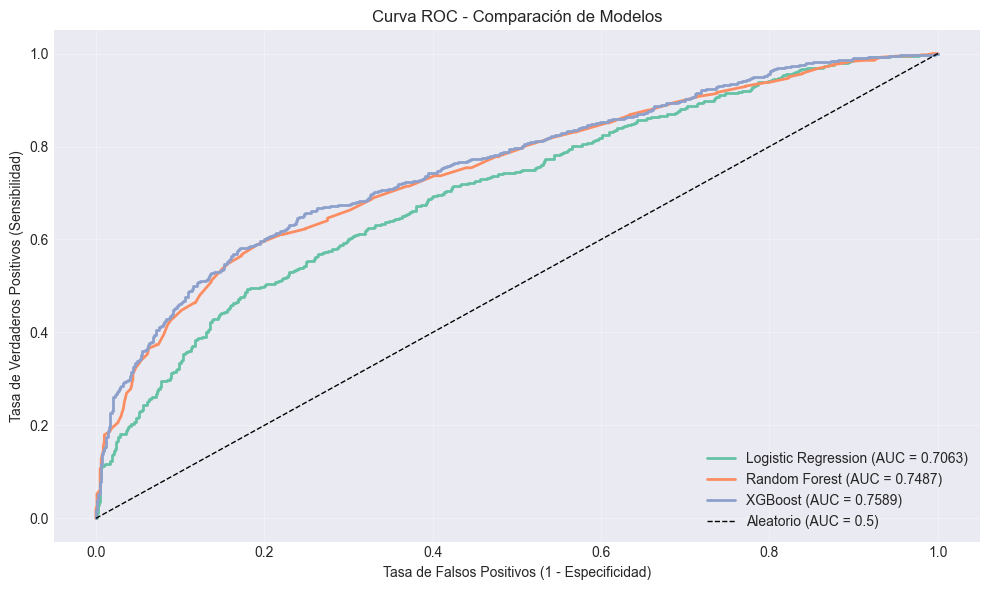


5. IMPORTANCIA DE VARIABLES

📊 TOP 10 VARIABLES MÁS IMPORTANTES:
              variable  importancia
         HABITO_PAGO_C     0.093475
           CODEUDOR_Si     0.068706
        CAPACIDAD_PAGO     0.065520
  SUBTIPO_CLIENTE_INFO     0.042397
     RATIO_CUOTA_VALOR     0.039598
      CARGA_FINANCIERA     0.038952
         HABITO_PAGO_E     0.038952
        Puntaje Riesgo     0.030652
ZONA_ZONA EJE CAFETERO     0.026221
   RATIO_VALOR_INGRESO     0.024675


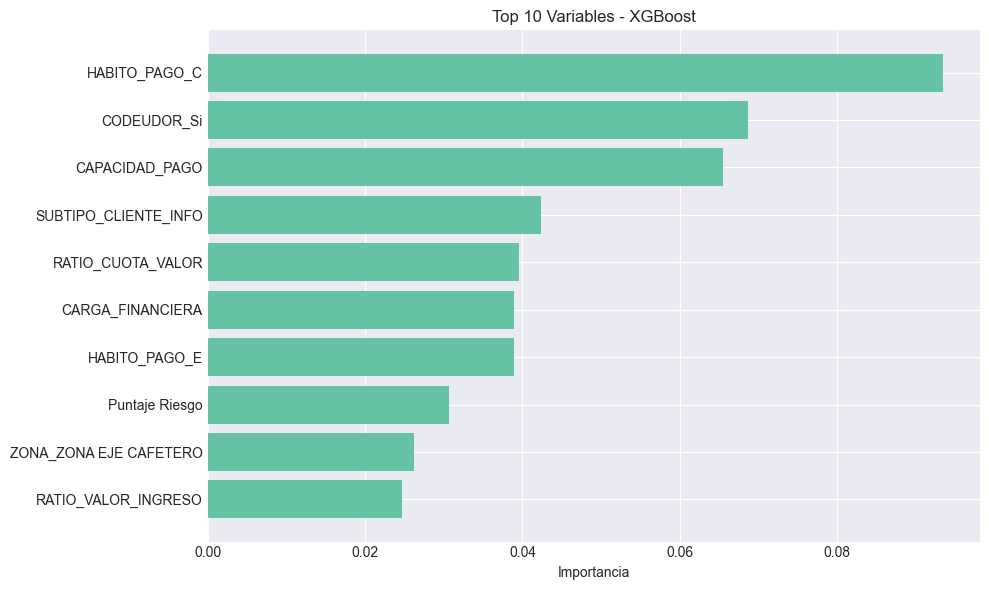


6. CURVA PRECISIÓN-RECALL


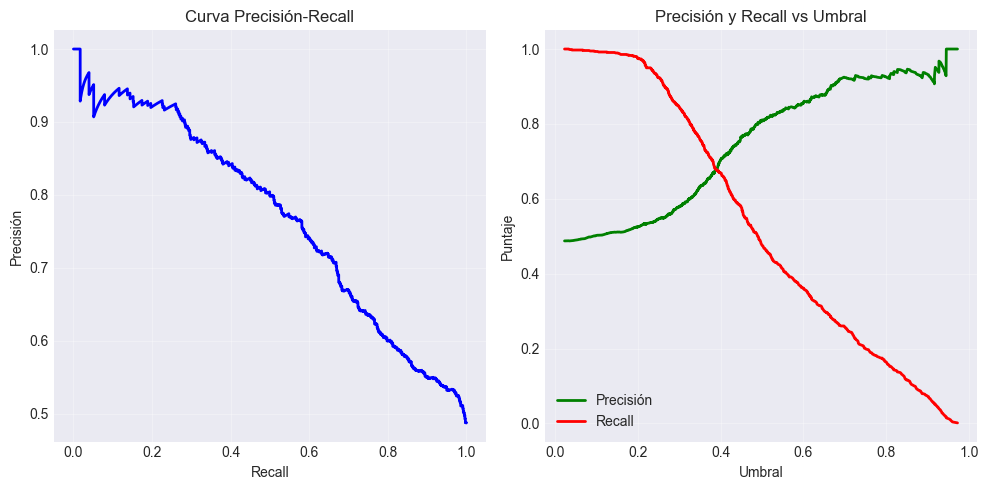


7. MÉTRICAS ADICIONALES

📊 Métricas de negocio:

  • Precisión (Precision): 0.809 
    → De los que predijo como desistidos, cuánto acertó

  • Sensibilidad (Recall): 0.476
    → De los desistidos reales, cuánto detectó

  • Especificidad: 0.893
    → De los no desistidos reales, cuánto detectó

  • F1-Score: 0.599
    → Balance entre precisión y sensibilidad

🎯 Interpretación para el negocio:
  → El modelo detecta correctamente al 47.6% de los desistidos
  → Pero 10.7% de los no desistidos son marcados erróneamente



In [33]:
# ============================================
# 2. COMPARACIÓN DE MODELOS
# ============================================

print("\n" + "="*80)
print("2. COMPARACIÓN DE MODELOS")
print("="*80)

# Tabla comparativa
comparison = pd.DataFrame({
    'Modelo': list(results.keys()),
    'AUC': [results[m]['auc'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results]
}).sort_values('AUC', ascending=False)

print("\n📊 Ranking de modelos:")
print(comparison.to_string(index=False))

# Gráfico de barras comparativo
plt.figure(figsize=(10, 5))
x = range(len(comparison))
width = 0.35

plt.bar([i - width/2 for i in x], comparison['AUC'], width, label='AUC', color='steelblue')
plt.bar([i + width/2 for i in x], comparison['F1-Score'], width, label='F1-Score', color='coral')
plt.xticks(x, comparison['Modelo'])
plt.ylabel('Puntaje')
plt.title('Comparación de Modelos')
plt.legend()
plt.ylim(0, 1)
for i, row in comparison.iterrows():
    plt.text(i - width/2, row['AUC'] + 0.02, f"{row['AUC']:.3f}", ha='center', fontsize=9)
    plt.text(i + width/2, row['F1-Score'] + 0.02, f"{row['F1-Score']:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 3. MEJOR MODELO
# ============================================

print("\n" + "="*80)
print("3. MEJOR MODELO - XGBoost")
print("="*80)

best_model = results['XGBoost']['model']
y_pred_best = results['XGBoost']['y_pred']
y_proba_best = results['XGBoost']['y_proba']

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Desistida', 'Desistida'],
            yticklabels=['No Desistida', 'Desistida'])
plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Desistida', 'Desistida']))

# ============================================
# 4. CURVA ROC
# ============================================

print("\n" + "="*80)
print("4. CURVA ROC")
print("="*80)

plt.figure(figsize=(10, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {res["auc"]:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 5. IMPORTANCIA DE VARIABLES (XGBoost)
# ============================================

print("\n" + "="*80)
print("5. IMPORTANCIA DE VARIABLES")
print("="*80)

feature_importance = pd.DataFrame({
    'variable': X_train.columns,
    'importancia': best_model.feature_importances_
}).sort_values('importancia', ascending=False)

print("\n📊 TOP 10 VARIABLES MÁS IMPORTANTES:")
print(feature_importance.head(10).to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importancia'].values)
plt.yticks(range(len(top_features)), top_features['variable'].values)
plt.xlabel('Importancia')
plt.title('Top 10 Variables - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================
# 6. CURVA PRECISIÓN-RECALL
# ============================================

print("\n" + "="*80)
print("6. CURVA PRECISIÓN-RECALL")
print("="*80)

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(recall, precision, 'b-', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curva Precisión-Recall')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(thresholds, precision[:-1], 'g-', label='Precisión', linewidth=2)
plt.plot(thresholds, recall[:-1], 'r-', label='Recall', linewidth=2)
plt.xlabel('Umbral')
plt.ylabel('Puntaje')
plt.title('Precisión y Recall vs Umbral')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. MÉTRICAS ADICIONALES
# ============================================

print("\n" + "="*80)
print("7. MÉTRICAS ADICIONALES")
print("="*80)

tn, fp, fn, tp = cm.ravel()

print(f"""
📊 Métricas de negocio:

  • Precisión (Precision): {tp/(tp+fp):.3f} 
    → De los que predijo como desistidos, cuánto acertó

  • Sensibilidad (Recall): {tp/(tp+fn):.3f}
    → De los desistidos reales, cuánto detectó

  • Especificidad: {tn/(tn+fp):.3f}
    → De los no desistidos reales, cuánto detectó

  • F1-Score: {2*(tp/(tp+fp))*(tp/(tp+fn))/((tp/(tp+fp))+(tp/(tp+fn))):.3f}
    → Balance entre precisión y sensibilidad

🎯 Interpretación para el negocio:
  → El modelo detecta correctamente al {tp/(tp+fn)*100:.1f}% de los desistidos
  → Pero {fp/(fp+tn)*100:.1f}% de los no desistidos son marcados erróneamente
""")

## 7. CONCLUSIÓN